# Árboles de decisión, Random Forest y XGBoost

**Unidad 9 · Machine Learning · Notebook 3 de 6**

Cierra el bloque supervisado. Cambia la familia de modelos: en lugar de una frontera lineal,
**particiones sucesivas del espacio**.

## La pregunta de este notebook

En `9.2` la regresión logística clasificaba a partir de una frontera lineal. Su limitación es
estructural: no puede representar interacciones ni relaciones no monótonas salvo que se las
especifique a mano.

Los árboles y sus ensambles no tienen esa restricción. Aprenden interacciones sin que nadie las
declare, y su frontera puede tener cualquier forma. La pregunta es directa:

> **¿Esa flexibilidad adicional mejora la predicción?**

Para responderla necesitamos datos donde los métodos tengan lugar para mostrarse, así que
cambiamos de dataset: **7.233 mesas de la elección legislativa porteña de 2025**. Es un problema
político real, con miles de observaciones y un baseline del 50%.

Además de la teoría de los tres métodos, van a aparecer cuatro cosas que solo se ven con datos
de este tamaño:

- la progresión **árbol → bosque → boosting**, con una sorpresa en el medio: Random Forest con
  los valores por defecto queda **por debajo** de un árbol único bien calibrado;
- la **trampa de las variables de alta cardinalidad**, con un caso real de 1.122 niveles;
- cómo se chequea si las observaciones son **independientes**;
- y un cierre aplicado que se puede **mapear**.

> El notebook complementario `9.3b.arboles-encuesta.ipynb` recorre los mismos métodos sobre la
> encuesta de 132 casos de `9.2`. Ahí el veredicto se invierte, y la comparación entre los dos
> es una de las lecciones centrales de la unidad. Conviene leerlo después de este.

## Requisitos

In [1]:
# Requisitos de este notebook.
# Si te falta alguno, instalalo EN TU PROPIO ENTORNO desde una terminal
# (o descomentando la linea de abajo) y reinicia el kernel:
#
#     pip install numpy pandas matplotlib seaborn scikit-learn statsmodels xgboost shap geopandas
#
# %pip install numpy pandas matplotlib seaborn scikit-learn statsmodels xgboost shap geopandas

import importlib

_requeridos = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn', 'statsmodels', 'xgboost', 'shap', 'geopandas']
_faltan = []
for _m in _requeridos:
    try:
        _mod = importlib.import_module(_m)
        print(f"  {_m:16s} {getattr(_mod, '__version__', 'sin version')}")
    except ImportError:
        _faltan.append(_m)
        print(f"  {_m:16s} FALTA")

if _faltan:
    print(f"\nFaltan {len(_faltan)} paquetes: {', '.join(_faltan)}.")
    print("Instalalos en tu entorno antes de seguir.")
else:
    print("\nTodo listo.")

  numpy            1.26.4
  pandas           2.2.2


  matplotlib       3.9.2


  seaborn          0.13.2


  sklearn          1.9.0
  statsmodels      0.14.2


  xgboost          3.4.1


  shap             0.46.0
  geopandas        1.1.1

Todo listo.


## Librerías

In [2]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score,
                             confusion_matrix, roc_auc_score)
from sklearn.model_selection import (StratifiedGroupKFold, StratifiedKFold,
                                     cross_val_predict, cross_validate, learning_curve,
                                     train_test_split, validation_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.width", 220)

SEED = 42
rng = np.random.default_rng(SEED)
PALETA = ["#0073C2", "#EFC000", "#CD534C", "#868686", "#1E2749"]

## Los datos: mesa por mesa

`mesas25.csv` tiene el resultado de la elección de legisladores de la Ciudad de Buenos Aires
de 2025, **desagregado por mesa de votación**. Una fila por mesa, con los votos de cada una de
las 17 listas más los votos en blanco, nulos, recurridos y el padrón.

Es el nivel de desagregación más fino disponible públicamente en datos electorales argentinos,
y por eso es tan útil: 7.268 unidades de análisis con comportamiento electoral medido sin
error de muestreo.

In [3]:
mesas = pd.read_csv("../../dataset/elecciones_caba_2025/mesas25.csv")
print(f"mesas: {mesas.shape[0]}   columnas: {mesas.shape[1]}")

NO_PARTIDOS = ["circuito", "comuna_x", "mesa", "escuela", "barrio", "comuna_y",
               "electores_totales", "cant_votantes", "voto_en_blanco",
               "votos_de_identidad_impugnada", "votos_nulos", "votos_recurridos",
               "no_voto", "comuna"]
PARTIDOS = [c for c in mesas.columns if c not in NO_PARTIDOS]

total = mesas[PARTIDOS].sum().sort_values(ascending=False)
pd.DataFrame({"votos": total, "%": (total / total.sum() * 100).round(2)}).head(8)

mesas: 7268   columnas: 31


,votos,%
la_libertad_avanza,465048,30.25
es_ahora_buenos_aires,429196,27.91
buenos_aires_primero,254074,16.52
volvamos_buenos_aires,127379,8.28
frente_de_izquierda_y_de_trabajadores_-_unidad,49500,3.22
unión_del_centro_democrático,41008,2.67
coalición_cívica_-_afirmación_para_una_república_igualitaria,40646,2.64
evolución,36538,2.38


### La variable a explicar

Definimos la etiqueta como **qué lista ganó en cada mesa**. Es una decisión de diseño: podría
ser el porcentaje de una lista (regresión), la participación, el voto en blanco. Elegimos el
ganador porque es la pregunta con la que trabaja un analista de campaña.

In [4]:
mesas["ganador"] = mesas[PARTIDOS].idxmax(axis=1)
conteo = mesas["ganador"].value_counts()
pd.DataFrame({"mesas ganadas": conteo,
              "%": (conteo / len(mesas) * 100).round(2)})

,mesas ganadas,%
ganador,,
la_libertad_avanza,3636,50.03
es_ahora_buenos_aires,3597,49.49
buenos_aires_primero,35,0.48


La elección fue una **carrera de dos**: *La Libertad Avanza* ganó en 3.636 mesas y *Es Ahora
Buenos Aires* en 3.597. Un tercer espacio, *Buenos Aires Primero*, ganó en 35.

Nos quedamos con las dos primeras y descartamos esas 35 mesas. Con eso el problema queda
**binario y casi perfectamente balanceado**, lo que tiene una ventaja pedagógica que conviene
señalar: **el baseline es 50.3%**, así que por una vez la exactitud es una métrica honesta y
todo lo que supere 0.50 es señal real. En `9.2`, con clases desbalanceadas, había que mirar el
$F_1$ macro para no engañarse.

In [5]:
DOS = ["la_libertad_avanza", "es_ahora_buenos_aires"]
datos = mesas[mesas["ganador"].isin(DOS)].copy().reset_index(drop=True)

datos["participacion"] = datos["cant_votantes"] / datos["electores_totales"]
datos["margen"] = ((datos["la_libertad_avanza"] - datos["es_ahora_buenos_aires"])
                   / datos["cant_votantes"] * 100)

print(f"mesas conservadas: {len(datos)} de {len(mesas)}  "
      f"(se descartan {len(mesas) - len(datos)} donde ganó un tercer espacio)")
print(f"\nbaseline (clase mayoritaria): "
      f"{datos['ganador'].value_counts(normalize=True).iloc[0]:.4f}")
print(f"\nparticipación: media {datos['participacion'].mean():.3f}, "
      f"rango [{datos['participacion'].min():.3f}, {datos['participacion'].max():.3f}]")
print(f"padrón por mesa: media {datos['electores_totales'].mean():.0f}, "
      f"rango [{datos['electores_totales'].min()}, {datos['electores_totales'].max()}]")

mesas conservadas: 7233 de 7268  (se descartan 35 donde ganó un tercer espacio)

baseline (clase mayoritaria): 0.5027

participación: media 0.624, rango [0.286, 0.767]
padrón por mesa: media 346, rango [319, 350]


### Reconstruir los nombres de los barrios

La columna `barrio` es un **código numérico** de 1 a 48. Para poder leer los resultados hay
que recuperar los nombres, que están en el GeoJSON de barrios de la Ciudad.

No hay tabla de correspondencia, así que hay que inferir el criterio de codificación. La pista
está en que los códigos bajos corresponden todos a la comuna 1: el orden no es alfabético
global sino **por comuna y después alfabético dentro de cada comuna**.

In [6]:
with open("../../dataset/barrios_caba/caba_barrios.geojson", encoding="utf-8") as f:
    geojson_barrios = json.load(f)

geo = pd.DataFrame([{"nombre_barrio": f["properties"]["BARRIO"],
                     "comuna_geo": int(f["properties"]["COMUNA"])}
                    for f in geojson_barrios["features"]])

# hipótesis: los códigos se asignan ordenando por (comuna, nombre)
geo = geo.sort_values(["comuna_geo", "nombre_barrio"]).reset_index(drop=True)
geo["barrio"] = np.arange(1, len(geo) + 1)

# validación: la comuna del GeoJSON debe coincidir con la de las mesas para cada código
comuna_por_codigo = datos.groupby("barrio")["comuna_y"].agg(lambda s: s.mode().iloc[0])
control = geo.set_index("barrio").join(comuna_por_codigo.rename("comuna_mesas"))
coinciden = (control["comuna_geo"] == control["comuna_mesas"]).sum()

print(f"códigos cuya comuna coincide entre el GeoJSON y las mesas: {coinciden} de {len(control)}")
if coinciden == len(control):
    print("La hipótesis de codificación se valida en los 48 barrios.")
    datos = datos.merge(geo[["barrio", "nombre_barrio"]], on="barrio", how="left")
control.head(10)

códigos cuya comuna coincide entre el GeoJSON y las mesas: 48 de 48
La hipótesis de codificación se valida en los 48 barrios.


,nombre_barrio,comuna_geo,comuna_mesas
barrio,,,
1,CONSTITUCION,1,1
2,MONSERRAT,1,1
3,PUERTO MADERO,1,1
4,RETIRO,1,1
5,SAN NICOLAS,1,1
6,SAN TELMO,1,1
7,RECOLETA,2,2
8,BALVANERA,3,3
9,SAN CRISTOBAL,3,3


La validación es completa: los 48 códigos asignan la comuna correcta. Es un buen ejemplo de
una tarea cotidiana y poco glamorosa del trabajo con datos secundarios —reconstruir una
codificación no documentada— y de cómo **verificarla contra una variable independiente** en
lugar de asumir que la hipótesis es correcta.

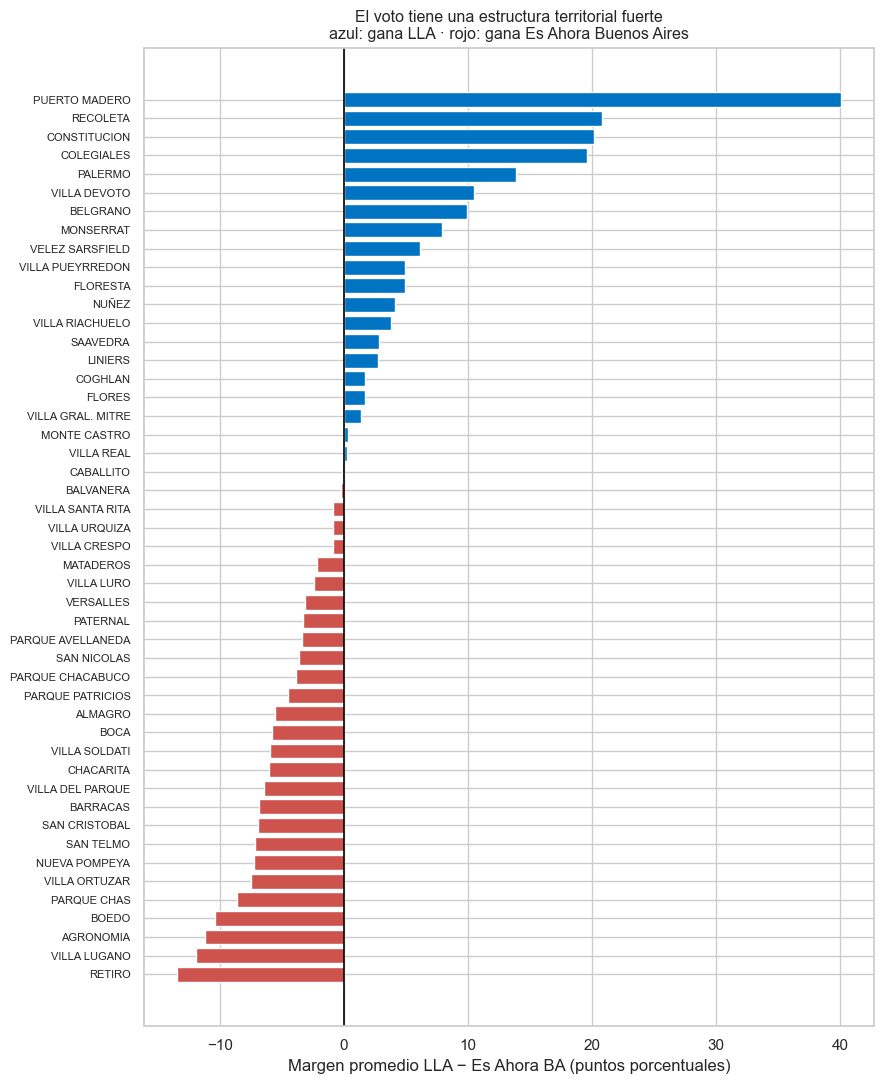

In [7]:
resumen_barrio = (datos.groupby("nombre_barrio")
                  .agg(mesas=("mesa", "size"),
                       participacion=("participacion", "mean"),
                       margen_lla=("margen", "mean"),
                       gana_lla=("ganador", lambda s: (s == "la_libertad_avanza").mean()))
                  .sort_values("margen_lla"))

fig, ax = plt.subplots(figsize=(9, 11))
colores = [PALETA[2] if v < 0 else PALETA[0] for v in resumen_barrio["margen_lla"]]
ax.barh(resumen_barrio.index, resumen_barrio["margen_lla"], color=colores)
ax.axvline(0, color="black", lw=1.2)
ax.set_xlabel("Margen promedio LLA − Es Ahora BA (puntos porcentuales)")
ax.set_title("El voto tiene una estructura territorial fuerte\n"
             "azul: gana LLA · rojo: gana Es Ahora Buenos Aires", fontsize=11.5)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

El gradiente es muy marcado: de unos $-20$ puntos en La Boca y Villa Soldati a más de $+20$ en
Puerto Madero y Palermo. Es el eje norte-sur que estructura históricamente el voto porteño, y
es la razón por la que el barrio va a ser el predictor dominante.

## Qué no puede entrar al modelo

Antes de elegir predictores, la pregunta de `9.0`: **¿qué información está disponible en el
momento de predecir?**

El dataset tiene 17 columnas con los votos de cada lista. Usarlas para predecir quién ganó
sería absurdo: **el ganador se calcula a partir de ellas**. Un modelo con esos predictores
tendría exactitud 1.0 y valor cero. Es el caso más obvio de fuga de información, pero el
mecanismo es idéntico al de `wbgi_cce` en `9.1`, donde no era obvio para nada.

Quedan cuatro predictores legítimos, todos conocidos **antes** de contar los votos:

| Predictor | Tipo | Qué capta |
|---|---|---|
| `nombre_barrio` | categórica, 48 niveles | ubicación: composición social del territorio |
| `comuna_y` | categórica, 15 niveles | agregación mayor del barrio |
| `electores_totales` | cuantitativa | tamaño del padrón de la mesa |
| `participacion` | cuantitativa | proporción del padrón que votó |

Notar que `participacion` **sí** es legítima aunque se conozca después de la votación: es un
dato del acto electoral, no del recuento por lista, y en un uso real de proyección se conoce
antes de terminar el escrutinio. Que sea legítima o no depende de para qué se use el modelo, y
eso hay que decidirlo explícitamente.

In [8]:
NUMERICAS = ["electores_totales", "participacion"]
CATEGORICAS = ["nombre_barrio", "comuna_y"]

X = datos[NUMERICAS + CATEGORICAS].copy()
X[NUMERICAS] = X[NUMERICAS].astype(float)
y = datos["ganador"]
y_bin = (y == "la_libertad_avanza").astype(int)

preprocesador = ColumnTransformer([
    ("num", StandardScaler(), NUMERICAS),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAS),
])

print(f"matriz de diseño: {preprocesador.fit_transform(X).shape}")
print(f"n = {len(X)}   ->  p/n = {preprocesador.fit_transform(X).shape[1] / len(X):.3f}")
print("\nRelación p/n opuesta a la de 9.1 y 9.3: acá sobran observaciones.")

matriz de diseño: (7233, 65)
n = 7233   ->  p/n = 0.009

Relación p/n opuesta a la de 9.1 y 9.3: acá sobran observaciones.


In [9]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
METRICAS = ["accuracy", "f1_macro", "roc_auc"]

def evaluar(estimador, X, y, nombre, cv=CV, **kw):
    r = cross_validate(estimador, X, y, cv=cv, scoring=METRICAS, n_jobs=-1, **kw)
    return {"modelo": nombre,
            "exactitud": r["test_accuracy"].mean(),
            "exac_sd": r["test_accuracy"].std(),
            "f1_macro": r["test_f1_macro"].mean(),
            "roc_auc": r["test_roc_auc"].mean()}

def con_pre(modelo):
    return Pipeline([("pre", preprocesador), ("clf", modelo)])

## Teoría: qué hace un árbol de decisión

Un árbol parte el espacio de predictores en regiones rectangulares y asigna una predicción
constante a cada región. El procedimiento es **recursivo y voraz** (*greedy*):

1. Considerar todos los cortes posibles de la forma $x_j \le c$, para toda variable $j$ y todo
   umbral $c$.
2. Elegir el corte que produzca la mayor reducción de **impureza**.
3. Repetir dentro de cada una de las dos regiones resultantes.
4. Detenerse cuando se cumple un criterio de parada.

"Voraz" quiere decir que en cada paso elige el mejor corte **local**, sin evaluar si un corte
peor ahora habilitaría uno mucho mejor después. No garantiza el árbol óptimo global —encontrarlo
es un problema NP-completo— pero es rápido y funciona bien en la práctica.

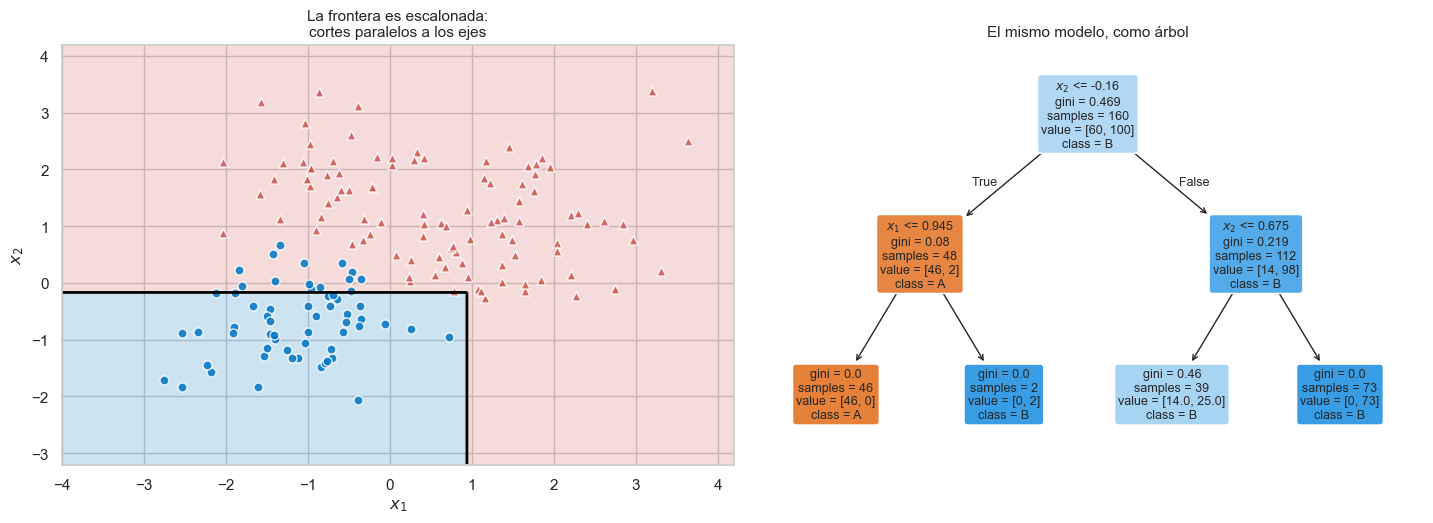

In [10]:
# Un árbol de profundidad 2 sobre dos variables: el espacio partido y el árbol, lado a lado
rng_demo = np.random.default_rng(SEED)
Xj = np.vstack([rng_demo.normal([-1.1, -0.6], 0.85, (60, 2)),
                rng_demo.normal([1.5, 0.9], 0.85, (60, 2)),
                rng_demo.normal([-0.8, 1.9], 0.7, (40, 2))])
yj = np.r_[np.zeros(60), np.ones(100)]

arbol_demo = DecisionTreeClassifier(max_depth=2, random_state=SEED).fit(Xj, yj)

fig = plt.figure(figsize=(14.5, 5.4))
ax1 = fig.add_subplot(1, 2, 1)
g1, g2 = np.meshgrid(np.linspace(-4, 4.2, 400), np.linspace(-3.2, 4.2, 400))
Z = arbol_demo.predict(np.c_[g1.ravel(), g2.ravel()]).reshape(g1.shape)
ax1.contourf(g1, g2, Z, alpha=0.20, colors=[PALETA[0], PALETA[2]], levels=[-0.5, 0.5, 1.5])
ax1.contour(g1, g2, Z, levels=[0.5], colors="black", linewidths=2)
for k, (color, marcador) in enumerate(zip([PALETA[0], PALETA[2]], ["o", "^"])):
    mm = yj == k
    ax1.scatter(Xj[mm, 0], Xj[mm, 1], s=42, color=color, marker=marcador,
                alpha=0.85, edgecolor="white")
ax1.set_xlabel("$x_1$"); ax1.set_ylabel("$x_2$")
ax1.set_title("La frontera es escalonada:\ncortes paralelos a los ejes", fontsize=11)

ax2 = fig.add_subplot(1, 2, 2)
plot_tree(arbol_demo, feature_names=["$x_1$", "$x_2$"], class_names=["A", "B"],
          filled=True, rounded=True, impurity=True, fontsize=9, ax=ax2)
ax2.set_title("El mismo modelo, como árbol", fontsize=11)
plt.tight_layout()
plt.show()

Los dos paneles son **el mismo objeto**. Cada nodo interno del árbol es una línea del gráfico
izquierdo; cada hoja es una región.

De ahí se siguen las dos características centrales de los árboles:

- **La frontera es escalonada y paralela a los ejes.** Un árbol no puede representar una frontera
  diagonal con un corte: la aproxima con una escalera. Es lo inverso de la logística, que solo
  puede hacer diagonales.
- **Capturan interacciones gratis.** El significado del segundo corte depende de por qué rama se
  llegó, y eso es exactamente una interacción. En un modelo lineal habría que agregar el término
  $x_1 \cdot x_2$ a mano.

Un árbol tampoco necesita que las variables estén escaladas: sus cortes son del tipo
$x_j \le c$ y no cambian si la variable se reescala. Es una ventaja práctica frente a los métodos
de `9.1` y `9.2`, donde estandarizar era obligatorio.

### La impureza: Gini y entropía

Para elegir un corte hace falta medir cuán "mezclado" está un nodo. Con $K$ clases y proporciones
$p_1, \dots, p_K$ dentro del nodo, las dos medidas habituales son:

$$ \text{Gini} = 1 - \sum_{k=1}^{K} p_k^2 \qquad\qquad
   \text{Entropía} = -\sum_{k=1}^{K} p_k \log_2 p_k $$

Las dos valen **0** cuando el nodo es puro y alcanzan su **máximo** cuando las clases están
repartidas en partes iguales.

La **ganancia de información** de un corte es la reducción ponderada de impureza:

$$ \Delta = I(\text{padre}) - \frac{n_{\text{izq}}}{n} I(\text{izq})
   - \frac{n_{\text{der}}}{n} I(\text{der}) $$

El algoritmo prueba todos los cortes y se queda con el de mayor $\Delta$.

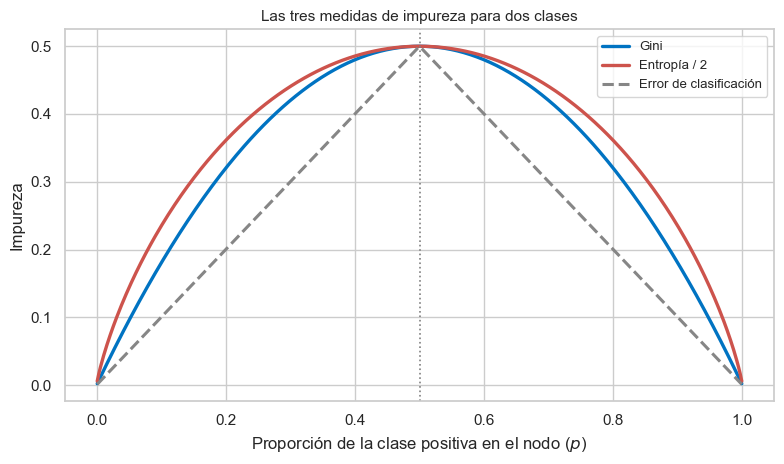

In [11]:
p = np.linspace(0.001, 0.999, 400)
gini = 1 - (p**2 + (1 - p)**2)
entropia = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))
error = 1 - np.maximum(p, 1 - p)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(p, gini, lw=2.4, color=PALETA[0], label="Gini")
ax.plot(p, entropia / 2, lw=2.4, color=PALETA[2], label="Entropía / 2")
ax.plot(p, error, lw=2.2, color=PALETA[3], ls="--", label="Error de clasificación")
ax.axvline(0.5, color="gray", ls=":", lw=1.2)
ax.set_xlabel("Proporción de la clase positiva en el nodo ($p$)")
ax.set_ylabel("Impureza")
ax.set_title("Las tres medidas de impureza para dos clases", fontsize=11)
ax.legend(fontsize=9.5)
plt.tight_layout()
plt.show()

Gini y entropía son casi indistinguibles una vez reescaladas, y en la práctica dan árboles muy
parecidos: la elección entre ellas casi nunca importa. Lo interesante es la tercera curva.

El **error de clasificación** es lineal a trozos, con un pico en 0.5. Eso lo hace mal criterio
para hacer crecer un árbol: un corte que mueve la proporción de 0.8 a 0.9 en una rama y de 0.8 a
0.7 en la otra no cambia el error total, así que el error no lo "premia" — pero sí cambió la
pureza, y Gini y entropía sí lo detectan porque son **estrictamente convexas**. Por eso se usa
Gini o entropía para crecer, y el error de clasificación recién al podar.

In [12]:
# La ganancia de información de los cortes candidatos, calculada a mano
def gini_nodo(y_nodo):
    if len(y_nodo) == 0:
        return 0.0
    p1 = y_nodo.mean()
    return 1 - (p1**2 + (1 - p1)**2)

y_arr = y_bin.to_numpy()
gini_raiz = gini_nodo(y_arr)
print(f"Impureza Gini del nodo raíz ({len(y_arr)} mesas): {gini_raiz:.4f}")
print("(cercana a 0.5 porque el problema está balanceado)\n")

def ganancia(mascara):
    izq, der = y_arr[~mascara], y_arr[mascara]
    n = len(y_arr)
    return gini_raiz - (len(izq) / n * gini_nodo(izq) + len(der) / n * gini_nodo(der))

candidatos = []
for umbral in np.percentile(datos["participacion"], [20, 35, 50, 65, 80]):
    candidatos.append({"corte": f"participacion <= {umbral:.3f}", "tipo": "continua",
                       "ganancia": ganancia((datos["participacion"] > umbral).to_numpy())})
for umbral in np.percentile(datos["electores_totales"], [35, 50, 65]):
    candidatos.append({"corte": f"electores_totales <= {umbral:.0f}", "tipo": "continua",
                       "ganancia": ganancia((datos["electores_totales"] > umbral).to_numpy())})
for c in sorted(datos["comuna_y"].unique()):
    candidatos.append({"corte": f"comuna == {c}", "tipo": "comuna (dummy)",
                       "ganancia": ganancia((datos["comuna_y"] == c).to_numpy())})
for barrio in datos["nombre_barrio"].value_counts().head(20).index:
    candidatos.append({"corte": f"barrio == {barrio}", "tipo": "barrio (dummy)",
                       "ganancia": ganancia((datos["nombre_barrio"] == barrio).to_numpy())})

tabla_gan = pd.DataFrame(candidatos).sort_values("ganancia", ascending=False)
print("Los 10 mejores cortes candidatos:\n")
print(tabla_gan.head(10).round(5).to_string(index=False))
print("\nMejor corte de cada tipo:")
print(tabla_gan.groupby("tipo")["ganancia"].max().round(5)
      .sort_values(ascending=False).to_string())

Impureza Gini del nodo raíz (7233 mesas): 0.5000
(cercana a 0.5 porque el problema está balanceado)

Los 10 mejores cortes candidatos:

               corte           tipo  ganancia
        comuna == 13 comuna (dummy)   0.02938
  barrio == RECOLETA barrio (dummy)   0.02533
         comuna == 2 comuna (dummy)   0.02533
barrio == COLEGIALES barrio (dummy)   0.02432
         comuna == 5 comuna (dummy)   0.01703
        comuna == 15 comuna (dummy)   0.01589
        comuna == 14 comuna (dummy)   0.01474
   barrio == PALERMO barrio (dummy)   0.01474
         comuna == 4 comuna (dummy)   0.01464
   barrio == ALMAGRO barrio (dummy)   0.00981

Mejor corte de cada tipo:
tipo
comuna (dummy)    0.02938
barrio (dummy)    0.02533
continua          0.00233


El ganador es **`comuna == 13`**, con una ganancia de 0.029. Y el patrón es claro: los cortes
**geográficos** le ganan a los continuos por un orden de magnitud. El mejor corte sobre la
participación consigue 0.002; el mejor sobre una comuna, 0.029.

Sustantivamente tiene todo el sentido. La comuna 13 es Belgrano, Colegiales y Núñez, y los
siguientes mejores cortes son Recoleta, la comuna 2 y Palermo: el corredor norte de la ciudad.
**El árbol está descubriendo el eje norte-sur del voto porteño** —la regularidad más conocida del
comportamiento electoral de la ciudad— y lo hace en su primer corte.

Es exactamente el cálculo que hace `DecisionTreeClassifier` internamente, sobre todos los
umbrales posibles de todas las columnas.

## Un árbol sobre los datos

Con nombres de barrio en lugar de códigos, un árbol de profundidad 3 produce reglas
directamente legibles.

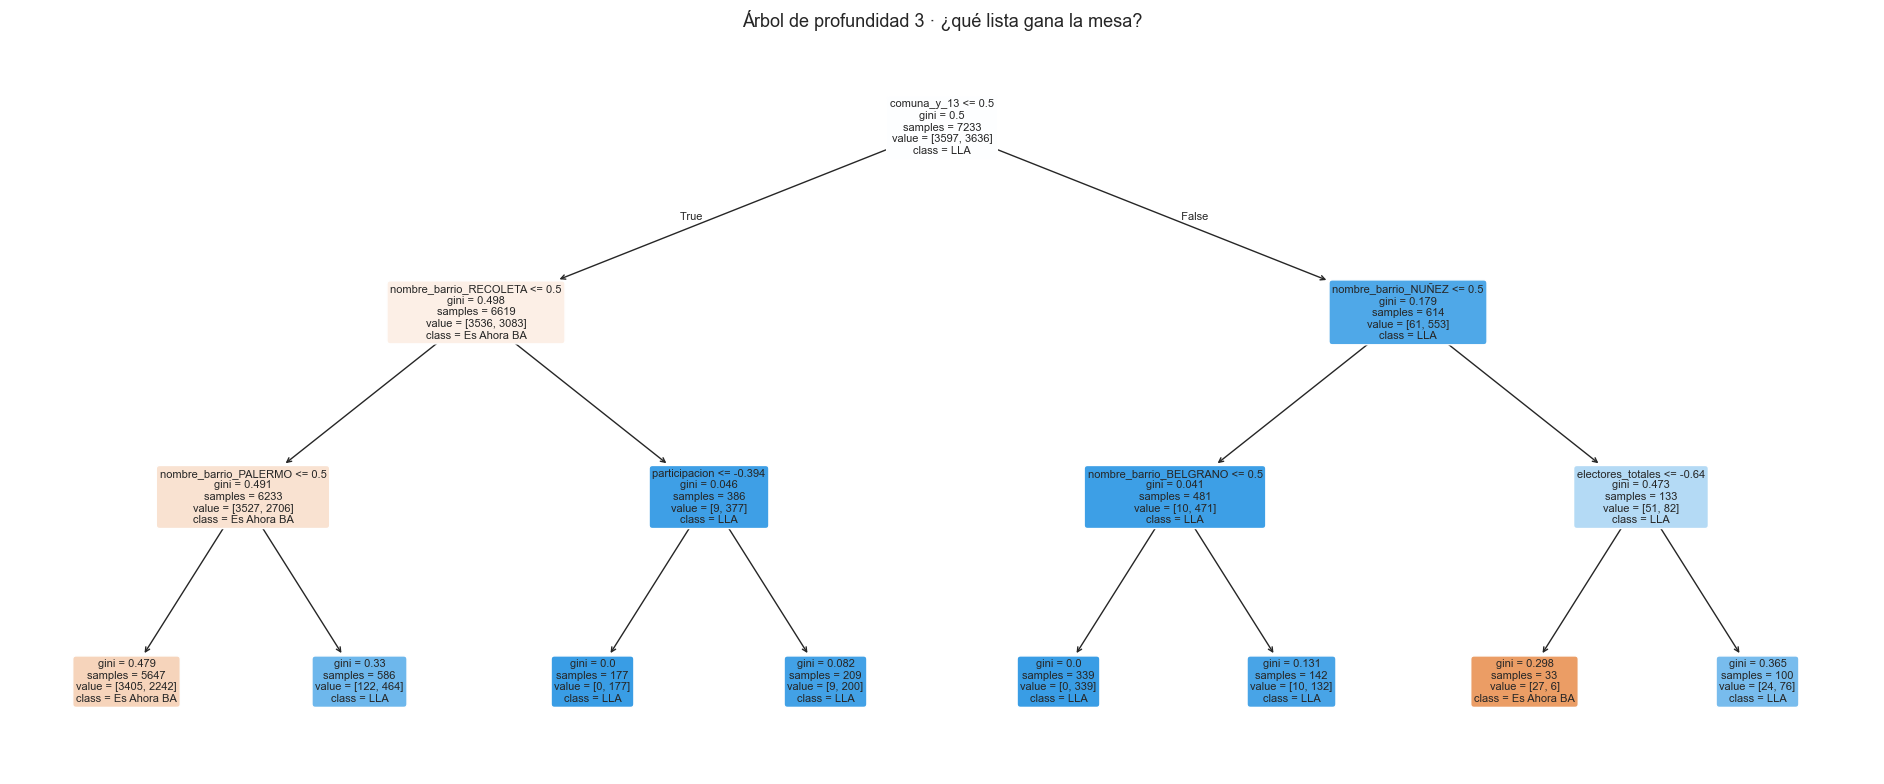

In [13]:
arbol3 = con_pre(DecisionTreeClassifier(max_depth=3, random_state=SEED))
arbol3.fit(X, y_bin)

nombres = [n.split("__", 1)[1] for n in arbol3[:-1].get_feature_names_out()]

fig, ax = plt.subplots(figsize=(19, 8))
plot_tree(arbol3[-1], feature_names=nombres,
          class_names=["Es Ahora BA", "LLA"], filled=True, rounded=True,
          fontsize=8, ax=ax)
ax.set_title("Árbol de profundidad 3 · ¿qué lista gana la mesa?", fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
print(export_text(arbol3[-1], feature_names=nombres,
                  class_names=["Es Ahora BA", "LLA"], max_depth=3,
                  spacing=2, decimals=2))

|-- comuna_y_13 <= 0.50
|  |-- nombre_barrio_RECOLETA <= 0.50
|  |  |-- nombre_barrio_PALERMO <= 0.50
|  |  |  |-- class: Es Ahora BA
|  |  |-- nombre_barrio_PALERMO >  0.50
|  |  |  |-- class: LLA
|  |-- nombre_barrio_RECOLETA >  0.50
|  |  |-- participacion <= -0.39
|  |  |  |-- class: LLA
|  |  |-- participacion >  -0.39
|  |  |  |-- class: LLA
|-- comuna_y_13 >  0.50
|  |-- nombre_barrio_NUÑEZ <= 0.50
|  |  |-- nombre_barrio_BELGRANO <= 0.50
|  |  |  |-- class: LLA
|  |  |-- nombre_barrio_BELGRANO >  0.50
|  |  |  |-- class: LLA
|  |-- nombre_barrio_NUÑEZ >  0.50
|  |  |-- electores_totales <= -0.64
|  |  |  |-- class: Es Ahora BA
|  |  |-- electores_totales >  -0.64
|  |  |  |-- class: LLA



Las reglas confirman lo que anticipaba el cálculo de ganancia: el árbol parte primero por
**comuna 13** y después sigue discriminando por barrio —Recoleta, Palermo, Belgrano, Núñez—. La
participación y el padrón aparecen recién en las hojas, como criterio de desempate dentro de un
barrio.

O sea que el modelo, dejado a su criterio, construye una **regla territorial**: casi todo lo que
necesita saber para predecir quién gana una mesa es dónde está esa mesa.

Y notar la estructura: el significado del segundo corte depende de por qué rama se llegó al
primero. Eso es una interacción entre territorio y participación, y el árbol la encontró sin que
nadie la declarara. En un modelo lineal habría que especificarla a mano.

C:\Users\mmill\anaconda3\envs\PYR\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


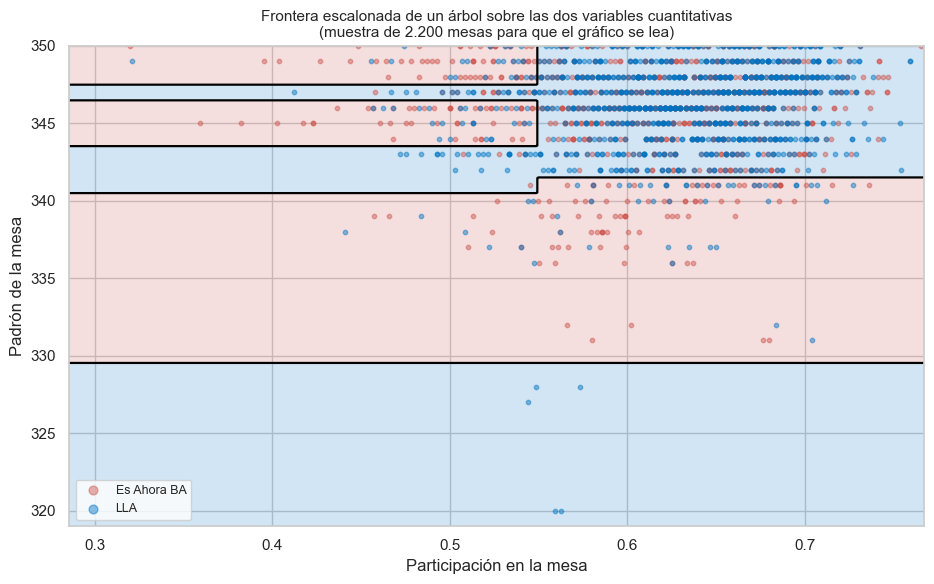

In [15]:
# La frontera de decisión sobre las dos variables cuantitativas
sub = datos.sample(2200, random_state=SEED)
arbol_2d = DecisionTreeClassifier(max_depth=4, random_state=SEED).fit(
    datos[["participacion", "electores_totales"]], y_bin)

g1, g2 = np.meshgrid(np.linspace(datos["participacion"].min(), datos["participacion"].max(), 400),
                     np.linspace(datos["electores_totales"].min(),
                                 datos["electores_totales"].max(), 400))
Z = arbol_2d.predict(np.c_[g1.ravel(), g2.ravel()]).reshape(g1.shape)

fig, ax = plt.subplots(figsize=(9.5, 6))
ax.contourf(g1, g2, Z, alpha=0.18, colors=[PALETA[2], PALETA[0]], levels=[-0.5, 0.5, 1.5])
ax.contour(g1, g2, Z, levels=[0.5], colors="black", linewidths=1.6)
for etiqueta, color, nombre in [(0, PALETA[2], "Es Ahora BA"), (1, PALETA[0], "LLA")]:
    m = (sub["ganador"] == "la_libertad_avanza").astype(int) == etiqueta
    ax.scatter(sub.loc[m, "participacion"], sub.loc[m, "electores_totales"],
               s=10, color=color, alpha=0.45, label=nombre)
ax.set_xlabel("Participación en la mesa")
ax.set_ylabel("Padrón de la mesa")
ax.set_title("Frontera escalonada de un árbol sobre las dos variables cuantitativas\n"
             "(muestra de 2.200 mesas para que el gráfico se lea)", fontsize=11)
ax.legend(fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()

Con 7.233 puntos se ve bien la naturaleza escalonada de la frontera: bloques rectangulares,
sin diagonales. La participación hace casi todo el trabajo; el tamaño del padrón, poco.

## Poda: ahora la curva de validación tiene un máximo claro

Con 7.233 casos el compromiso sesgo-varianza se ve con nitidez. (En `9.3b`, con 132 casos, esta
misma curva es plana y ruidosa: no alcanza para distinguir profundidades.)

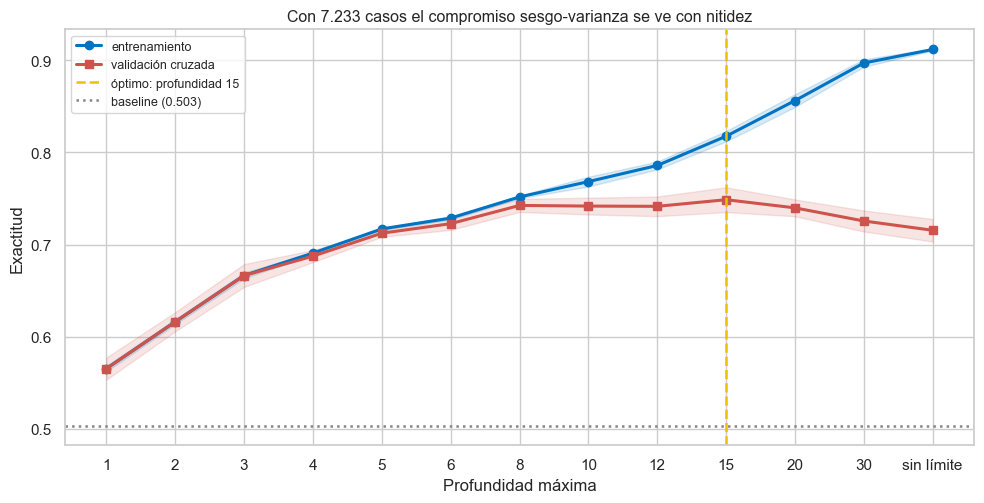

profundidad óptima: 15   exactitud = 0.7486
árbol sin límite  : entrenamiento = 0.9117   validación = 0.7155


In [16]:
profundidades = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 30, None]
etiquetas_prof = [str(p) if p is not None else "sin límite" for p in profundidades]

tr, te = validation_curve(
    con_pre(DecisionTreeClassifier(random_state=SEED)), X, y_bin,
    param_name="clf__max_depth", param_range=profundidades,
    cv=CV, scoring="accuracy", n_jobs=-1)

posiciones = np.arange(len(profundidades))
fig, ax = plt.subplots(figsize=(10, 5.2))
ax.plot(posiciones, tr.mean(axis=1), "o-", lw=2.2, color=PALETA[0], label="entrenamiento")
ax.fill_between(posiciones, tr.mean(axis=1) - tr.std(axis=1),
                tr.mean(axis=1) + tr.std(axis=1), alpha=0.15, color=PALETA[0])
ax.plot(posiciones, te.mean(axis=1), "s-", lw=2.2, color=PALETA[2], label="validación cruzada")
ax.fill_between(posiciones, te.mean(axis=1) - te.std(axis=1),
                te.mean(axis=1) + te.std(axis=1), alpha=0.15, color=PALETA[2])
mejor_i = int(np.argmax(te.mean(axis=1)))
ax.axvline(mejor_i, color=PALETA[1], ls="--", lw=1.8,
           label=f"óptimo: profundidad {etiquetas_prof[mejor_i]}")
ax.axhline(0.5027, color=PALETA[3], ls=":", lw=1.8, label="baseline (0.503)")
ax.set_xticks(posiciones); ax.set_xticklabels(etiquetas_prof)
ax.set_xlabel("Profundidad máxima")
ax.set_ylabel("Exactitud")
ax.set_title("Con 7.233 casos el compromiso sesgo-varianza se ve con nitidez", fontsize=11.5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"profundidad óptima: {etiquetas_prof[mejor_i]}   "
      f"exactitud = {te.mean(axis=1)[mejor_i]:.4f}")
print(f"árbol sin límite  : entrenamiento = {tr.mean(axis=1)[-1]:.4f}   "
      f"validación = {te.mean(axis=1)[-1]:.4f}")

Esta es la curva del libro de texto. El entrenamiento sube monótonamente hacia 1.0 —un árbol sin
restricciones puede memorizar cada mesa— mientras la validación sube, alcanza un máximo y baja.
**La brecha entre las dos curvas es la varianza del modelo**, y se abre exactamente donde empieza
el sobreajuste.

### Poda por complejidad-costo

Fijar `max_depth` a ojo funciona, pero la forma disciplinada de controlar el tamaño del árbol es
**hacerlo crecer completo y después podarlo**. Se minimiza

$$ R_\alpha(T) = R(T) + \alpha \, |T| $$

donde $R(T)$ es el error del árbol, $|T|$ su cantidad de hojas y $\alpha \geq 0$ el precio de
cada hoja. Con $\alpha = 0$ se obtiene el árbol completo; al subir $\alpha$ se van colapsando
ramas.

Es la misma idea que Ridge y Lasso en `9.1`: **una penalización sobre la complejidad, calibrada
por validación cruzada.** Lo que se penaliza acá es la cantidad de hojas en lugar de la magnitud
de los coeficientes.

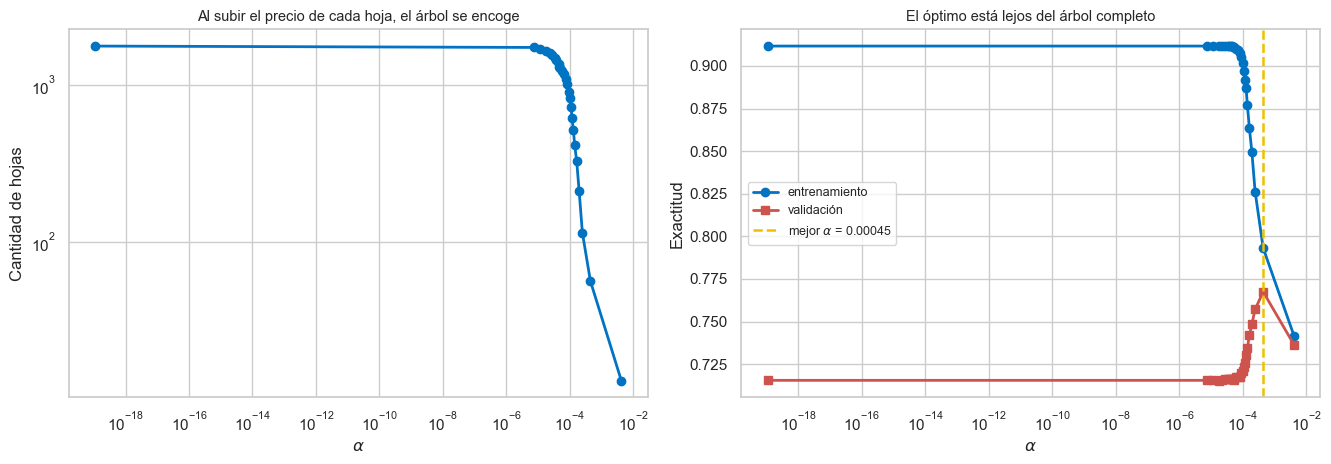

árbol completo :  1820 hojas, profundidad 48
árbol podado   :    56 hojas, profundidad 25


In [17]:
X_mat = preprocesador.fit_transform(X)
arbol_completo = DecisionTreeClassifier(random_state=SEED).fit(X_mat, y_bin)
camino = arbol_completo.cost_complexity_pruning_path(X_mat, y_bin)
alphas = camino.ccp_alphas[camino.ccp_alphas > 0]
alphas = alphas[::max(1, len(alphas) // 25)]        # una muestra del camino, para que corra rápido

hojas = [DecisionTreeClassifier(random_state=SEED, ccp_alpha=a).fit(X_mat, y_bin).get_n_leaves()
         for a in alphas]

tr_p, te_p = validation_curve(
    con_pre(DecisionTreeClassifier(random_state=SEED)), X, y_bin,
    param_name="clf__ccp_alpha", param_range=alphas, cv=CV, scoring="accuracy", n_jobs=-1)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
axes[0].plot(alphas, hojas, "o-", color=PALETA[0], lw=2)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel(r"$\alpha$"); axes[0].set_ylabel("Cantidad de hojas")
axes[0].set_title("Al subir el precio de cada hoja, el árbol se encoge", fontsize=10.5)

axes[1].plot(alphas, tr_p.mean(axis=1), "o-", color=PALETA[0], lw=2, label="entrenamiento")
axes[1].plot(alphas, te_p.mean(axis=1), "s-", color=PALETA[2], lw=2, label="validación")
mejor_a = alphas[int(np.argmax(te_p.mean(axis=1)))]
axes[1].axvline(mejor_a, color=PALETA[1], ls="--", lw=1.8,
                label=f"mejor $\\alpha$ = {mejor_a:.5f}")
axes[1].set_xscale("log")
axes[1].set_xlabel(r"$\alpha$"); axes[1].set_ylabel("Exactitud")
axes[1].set_title("El óptimo está lejos del árbol completo", fontsize=10.5)
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

t_podado = DecisionTreeClassifier(random_state=SEED, ccp_alpha=mejor_a).fit(X_mat, y_bin)
print(f"árbol completo : {arbol_completo.get_n_leaves():5d} hojas, "
      f"profundidad {arbol_completo.get_depth()}")
print(f"árbol podado   : {t_podado.get_n_leaves():5d} hojas, profundidad {t_podado.get_depth()}")

El árbol sin restricciones tiene cientos de hojas y la poda lo reduce drásticamente sin perder
exactitud de validación. Las dos palancas —`max_depth` y `ccp_alpha`— llegan a resultados
parecidos; la segunda tiene la ventaja de no requerir adivinar la profundidad de antemano.

## El problema de fondo: los árboles son inestables

El sobreajuste se controla podando. Hay un problema más profundo, y es el que motiva todo lo que
viene después: **un árbol cambia mucho ante cambios chicos en los datos**.

La causa está en la naturaleza voraz del algoritmo. El primer corte se decide con todos los
datos; si por azar de muestreo otro corte gana por poco, **todo el subárbol que sigue es
distinto**. Los errores se propagan hacia abajo y se amplifican.

Veámoslo: remuestreamos con reposición seis veces y ajustamos el mismo árbol.

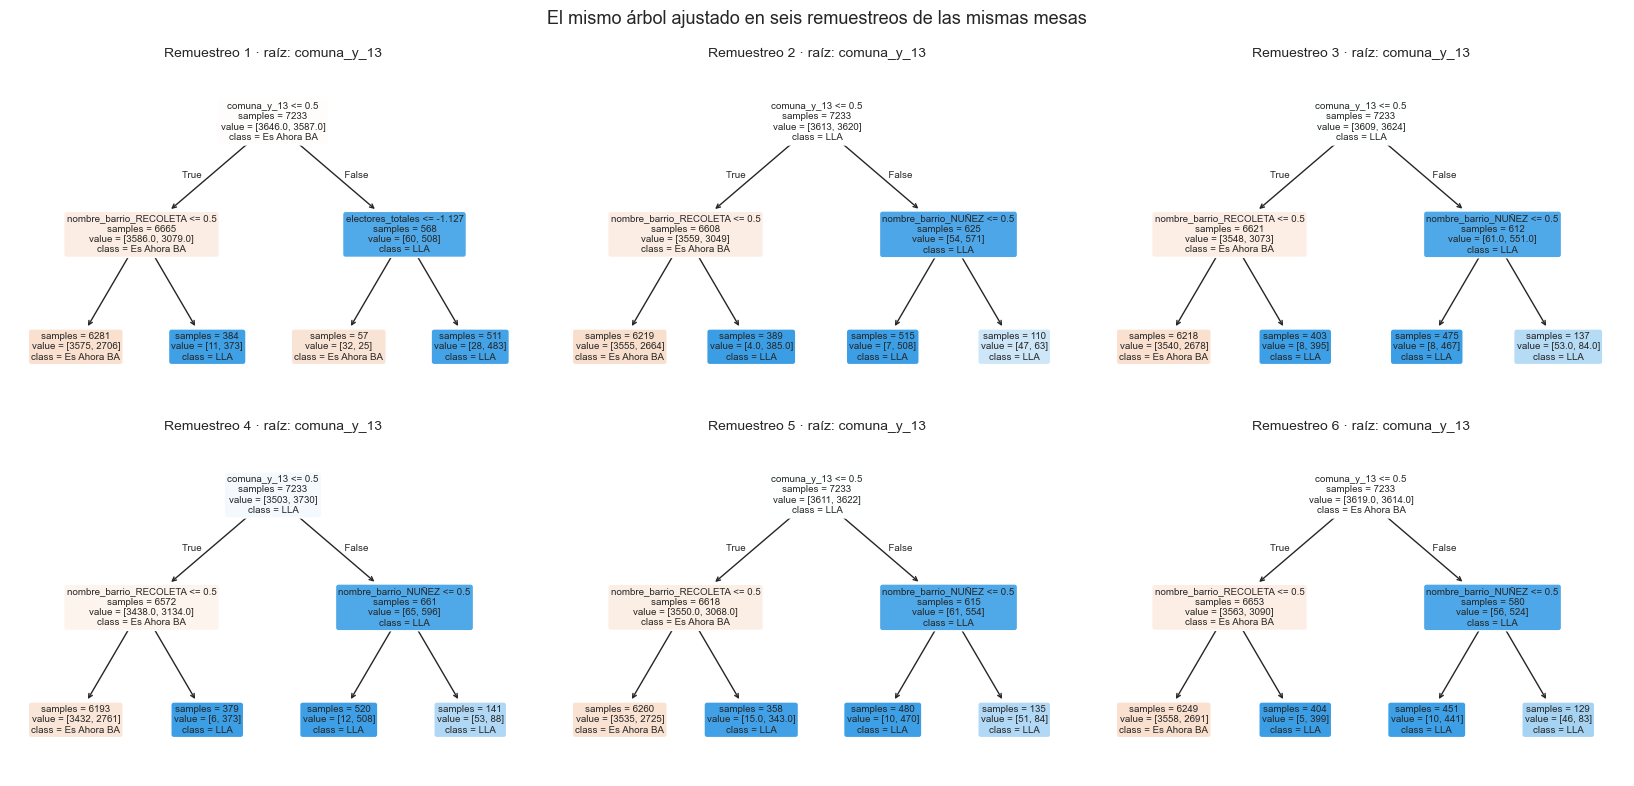

Variable de la raíz en cada remuestreo:
  1. comuna_y_13
  2. comuna_y_13
  3. comuna_y_13
  4. comuna_y_13
  5. comuna_y_13
  6. comuna_y_13

variables distintas en la raíz: 1 de 6


In [18]:
rng_boot = np.random.default_rng(SEED)
fig, axes = plt.subplots(2, 3, figsize=(16.5, 8))
raices = []

for k, ax in enumerate(axes.ravel()):
    idx = rng_boot.integers(0, len(X), len(X))
    t = DecisionTreeClassifier(max_depth=2, random_state=SEED).fit(X_mat[idx], y_bin.iloc[idx])
    plot_tree(t, feature_names=list(nombres), class_names=["Es Ahora BA", "LLA"],
              filled=True, rounded=True, fontsize=7, ax=ax, impurity=False)
    raiz = nombres[t.tree_.feature[0]]
    raices.append(raiz)
    ax.set_title(f"Remuestreo {k + 1} · raíz: {raiz}", fontsize=10)

fig.suptitle("El mismo árbol ajustado en seis remuestreos de las mismas mesas", fontsize=13)
plt.tight_layout()
plt.show()

print("Variable de la raíz en cada remuestreo:")
for k, r in enumerate(raices, 1):
    print(f"  {k}. {r}")
print(f"\nvariables distintas en la raíz: {len(set(raices))} de 6")

Con 7.233 casos la raíz es **perfectamente estable**: los seis remuestreos eligen `comuna 13`. Lo
que cambia son los cortes de abajo. Con la encuesta de 132 casos, en `9.3b`, cambia hasta la raíz.

Esa inestabilidad tiene dos consecuencias:

- **Para la predicción**: alta varianza, en el sentido exacto de `9.0`.
- **Para la interpretación**: es un problema serio y frecuentemente ignorado. Si un árbol elige
  una variable en la raíz y alguien concluye "esa es *la* variable determinante", la conclusión
  no es robusta. **La estructura de un árbol particular no es un hallazgo.**

La solución a la varianza es promediar muchos árboles. Hay dos formas de hacerlo, y son las dos
familias que siguen.

## Random Forest: promediar árboles en paralelo

### Bagging

*Bagging* viene de *bootstrap aggregating*. La receta:

1. Tomar $B$ muestras bootstrap (con reposición, del mismo tamaño que el original).
2. Ajustar un árbol **sin podar** en cada una.
3. Predecir por **voto mayoritario** entre los $B$ árboles.

Funciona por un resultado elemental: si se promedian $B$ variables con varianza $\sigma^2$ e
independientes, la varianza del promedio es $\sigma^2 / B$. Promediar reduce la varianza sin tocar
el sesgo. Y como los árboles profundos tienen sesgo bajo y varianza alta, son el candidato ideal.

El problema es el "independientes": los árboles del bagging están **correlacionados** entre sí,
porque se ajustan sobre datos muy parecidos y todos eligen los mismos predictores fuertes. Si hay
una variable dominante —acá, la participación— todos los árboles la ponen en la raíz.

### El aporte de Random Forest

Breiman agregó una idea simple y decisiva: **en cada corte, considerar solo un subconjunto
aleatorio de $m$ predictores** en lugar de todos. Por defecto $m = \sqrt{p}$ para clasificación.

Eso fuerza a los árboles a ser distintos entre sí: si la variable dominante no está entre las $m$
candidatas de un corte, ese árbol tiene que usar otra. **Decorrelaciona** los árboles, y el
promedio de árboles decorrelacionados reduce mucho más la varianza. El precio es que cada árbol
individual es algo peor.

<figure style="text-align:center; margin:1.4em 0;">
  <img src="media/singletree_vs_rf.png" width="820">
  <figcaption style="font-size:0.9em; color:#555;">
    Un árbol único contra un bosque. Cada árbol del bosque se ajustó sobre una muestra bootstrap
    distinta y puede llegar a una conclusión distinta: acá siete árboles votan "Class 1" y tres
    votan "Class 2".
  </figcaption>
</figure>

Notar que en la figura **los árboles se contradicen entre sí**, y eso no es un defecto: es el
mecanismo. Si todos coincidieran siempre, promediarlos no reduciría nada.

### Cómo predice el bosque un caso nuevo

Una observación nueva **recorre los $B$ árboles** y cada uno emite su predicción. Después se
agregan: por **voto mayoritario** en clasificación, por **promedio** en regresión.

<figure style="text-align:center; margin:1.4em 0;">
  <img src="media/rf.png" width="680">
  <figcaption style="font-size:0.9em; color:#555;">
    El camino de un caso nuevo por tres árboles del ensamble y la agregación final.
  </figcaption>
</figure>

De acá se sigue algo práctico: la **proporción de árboles** que votó por cada clase sirve como
estimación de probabilidad, y es lo que devuelve `predict_proba`. Si 220 de 300 árboles dicen
"LLA", la probabilidad estimada es 0.73. Esa probabilidad es la que vamos a usar en el cierre para
medir competitividad.

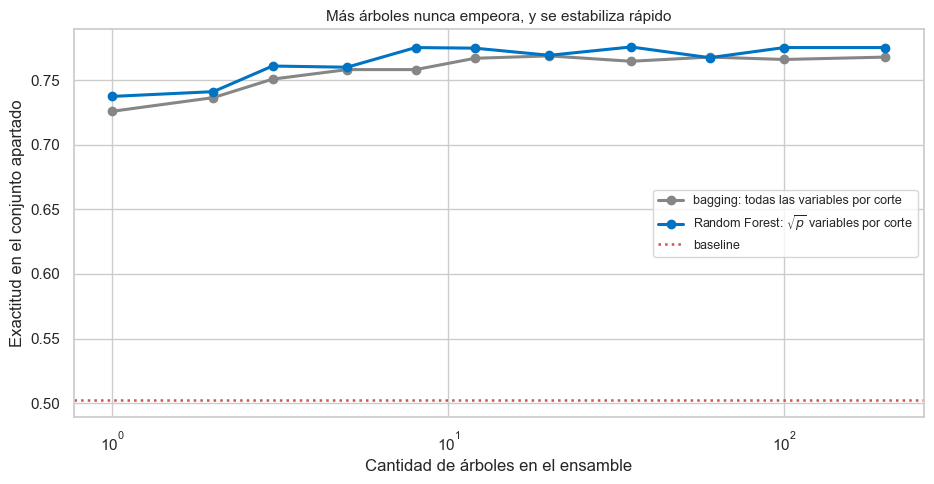

In [19]:
# Cómo mejora el bosque al agregar árboles, y el efecto del submuestreo de variables
n_arboles = [1, 2, 3, 5, 8, 12, 20, 35, 60, 100, 200]
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(X, y_bin, test_size=0.3,
                                              random_state=SEED, stratify=y_bin)

fig, ax = plt.subplots(figsize=(9.5, 5))
for max_feat, nombre, color in [(None, "bagging: todas las variables por corte", PALETA[3]),
                                ("sqrt", "Random Forest: $\\sqrt{p}$ variables por corte",
                                 PALETA[0])]:
    curva = []
    for b in n_arboles:
        m = con_pre(RandomForestClassifier(n_estimators=b, max_features=max_feat,
                                           min_samples_leaf=5, random_state=SEED, n_jobs=-1))
        m.fit(Xa_tr, ya_tr)
        curva.append(accuracy_score(ya_te, m.predict(Xa_te)))
    ax.plot(n_arboles, curva, "o-", lw=2.2, color=color, label=nombre)

ax.axhline(0.5027, color=PALETA[2], ls=":", lw=1.8, label="baseline")
ax.set_xscale("log")
ax.set_xlabel("Cantidad de árboles en el ensamble")
ax.set_ylabel("Exactitud en el conjunto apartado")
ax.set_title("Más árboles nunca empeora, y se estabiliza rápido", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

La curva sube y se aplana. A diferencia de `max_depth`, la cantidad de árboles **no es un
parámetro de sobreajuste**: agregar árboles nunca empeora el modelo, solo cuesta tiempo. Con unos
100 ya se estabiliza, y por eso `n_estimators` no se calibra finamente — se pone un número
generoso y listo.

Eso **no** significa que Random Forest no necesite calibración, y más abajo vamos a ver
exactamente dónde la necesita.

### Error out-of-bag

Un bonus del bootstrap: cada muestra deja afuera en promedio el $1/e \approx 37\%$ de las
observaciones. Cada caso puede entonces evaluarse con los árboles que **no** lo vieron, lo que da
una estimación del error de generalización **sin apartar datos ni hacer validación cruzada**.

In [20]:
rf = con_pre(RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1))

# error out-of-bag, gratis
rf_oob = RandomForestClassifier(n_estimators=300, oob_score=True,
                                random_state=SEED, n_jobs=-1)
rf_oob.fit(preprocesador.fit_transform(X), y_bin)
print(f"exactitud out-of-bag        : {rf_oob.oob_score_:.4f}")

s = cross_validate(rf, X, y_bin, cv=CV, scoring=["accuracy"], n_jobs=-1)
print(f"exactitud en validación cruz.: {s['test_accuracy'].mean():.4f} "
      f"± {s['test_accuracy'].std():.4f}")

exactitud out-of-bag        : 0.7315


exactitud en validación cruz.: 0.7290 ± 0.0145


### Importancia de las variables: dos formas, una correcta

Un bosque de 300 árboles ya no se lee como reglas. Para saber qué variables usa hay dos métodos,
y la diferencia entre ellos importa mucho.

**Importancia por impureza** (`feature_importances_`): suma, para cada variable, la reducción de
impureza que consiguió en todos los cortes donde se usó. Es gratis —sale del entrenamiento— pero
tiene un **sesgo conocido y serio**: favorece a las variables con **muchos valores distintos**,
porque ofrecen más cortes posibles y por azar alguno reduce la impureza. Una variable continua o
una categórica de alta cardinalidad aparece como importante incluso si es ruido puro.

**Importancia por permutación**: se mide la caída de performance al **desordenar al azar** una
columna del conjunto de validación. Si la variable importaba, romper su relación con la etiqueta
empeora las predicciones. Es más caro y usa datos no vistos, pero **no tiene el sesgo de
cardinalidad**.

Empecemos con los cuatro predictores actuales, donde los dos métodos deberían coincidir.

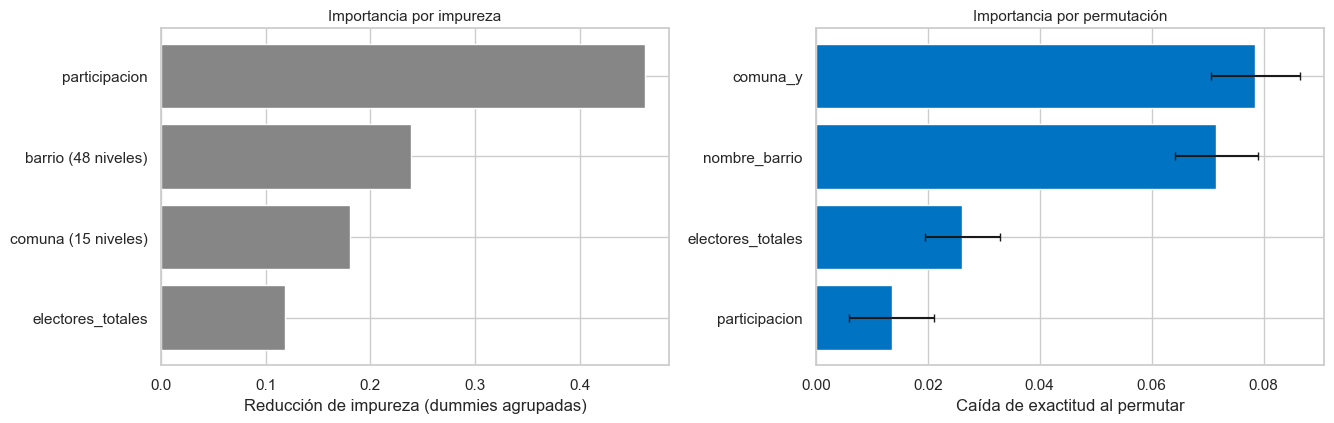

In [21]:
# Importancia: impureza vs permutación
X_tr, X_te, y_tr, y_te = train_test_split(X, y_bin, test_size=0.3,
                                          random_state=SEED, stratify=y_bin)
rf.fit(X_tr, y_tr)

cols = [n.split("__", 1)[1] for n in rf[:-1].get_feature_names_out()]
imp_gini = pd.Series(rf[-1].feature_importances_, index=cols)

# agrupamos las dummies de una misma variable original
def agrupar(serie):
    grupos = {}
    for k, v in serie.items():
        if k in NUMERICAS:
            base = k
        elif k.startswith("comuna_y"):
            base = "comuna (15 niveles)"
        else:
            base = "barrio (48 niveles)"
        grupos[base] = grupos.get(base, 0) + v
    return pd.Series(grupos).sort_values(ascending=False)

perm = permutation_importance(rf, X_te, y_te, n_repeats=15, random_state=SEED,
                              scoring="accuracy", n_jobs=-1)
imp_perm = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
g = agrupar(imp_gini).sort_values()
axes[0].barh(g.index, g.values, color=PALETA[3])
axes[0].set_xlabel("Reducción de impureza (dummies agrupadas)")
axes[0].set_title("Importancia por impureza", fontsize=11)

pp = imp_perm.sort_values()
axes[1].barh(pp.index, pp.values, xerr=pd.Series(perm.importances_std,
                                                 index=X.columns)[pp.index],
             capsize=3, color=PALETA[0])
axes[1].set_xlabel("Caída de exactitud al permutar")
axes[1].set_title("Importancia por permutación", fontsize=11)
plt.tight_layout()
plt.show()

Los dos métodos coinciden en el orden: **participación primero, barrio segundo**, y el padrón
casi no aporta. Cuando impureza y permutación coinciden, se puede confiar; el problema surge
cuando difieren, y para eso hay que provocarlo.

## La trampa de la alta cardinalidad, con un caso real

El dataset trae la variable ideal para provocar esa discrepancia: **`escuela`**, el
establecimiento donde funciona la mesa. Tiene **1.122 niveles** distintos para 7.233
observaciones, o sea unas 6 mesas por escuela.

Es exactamente el perfil de variable que la importancia por impureza sobrevalora. Y a la vez
es plausible que aporte información real: la escuela es una unidad geográfica más fina que el
barrio.

Las dos cosas pueden ser verdad a la vez, y hay que distinguirlas.

In [22]:
print(f"escuelas distintas: {datos['escuela'].nunique()}")
print(f"mesas por escuela : media {datos.groupby('escuela').size().mean():.1f}, "
      f"máximo {datos.groupby('escuela').size().max()}")

CAT_ESC = CATEGORICAS + ["escuela"]
X_esc = datos[NUMERICAS + CAT_ESC].copy()
X_esc[NUMERICAS] = X_esc[NUMERICAS].astype(float)

pre_esc = ColumnTransformer([
    ("num", StandardScaler(), NUMERICAS),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_ESC),
])
print(f"\nmatriz de diseño con escuela: {pre_esc.fit_transform(X_esc).shape}")

escuelas distintas: 1122
mesas por escuela : media 6.4, máximo 24

matriz de diseño con escuela: (7233, 1187)


In [23]:
rf_esc = Pipeline([("pre", pre_esc),
                   ("clf", RandomForestClassifier(n_estimators=300, random_state=SEED,
                                                  n_jobs=-1))])
Xe_tr, Xe_te, ye_tr, ye_te = train_test_split(X_esc, y_bin, test_size=0.3,
                                              random_state=SEED, stratify=y_bin)
rf_esc.fit(Xe_tr, ye_tr)

cols_esc = [n.split("__", 1)[1] for n in rf_esc[:-1].get_feature_names_out()]
imp_esc = pd.Series(rf_esc[-1].feature_importances_, index=cols_esc)

def agrupar_esc(serie):
    grupos = {}
    for k, v in serie.items():
        if k in NUMERICAS:
            base = k
        elif k.startswith("comuna_y"):
            base = "comuna (15 niveles)"
        elif k.startswith("escuela"):
            base = "escuela (1122 niveles)"
        else:
            base = "barrio (48 niveles)"
        grupos[base] = grupos.get(base, 0) + v
    return pd.Series(grupos).sort_values(ascending=False)

perm_esc = permutation_importance(rf_esc, Xe_te, ye_te, n_repeats=15,
                                  random_state=SEED, scoring="accuracy", n_jobs=-1)
imp_perm_esc = pd.Series(perm_esc.importances_mean, index=X_esc.columns)

comparacion_imp = pd.DataFrame({
    "por impureza": agrupar_esc(imp_esc),
    "por permutación": imp_perm_esc.rename(index={
        "nombre_barrio": "barrio (48 niveles)",
        "comuna_y": "comuna (15 niveles)",
        "escuela": "escuela (1122 niveles)"}),
}).round(4)
comparacion_imp

,por impureza,por permutación
barrio (48 niveles),0.1907,0.0311
comuna (15 niveles),0.1417,0.0547
electores_totales,0.0522,-0.0104
escuela (1122 niveles),0.3064,-0.0398
participacion,0.3090,-0.0009


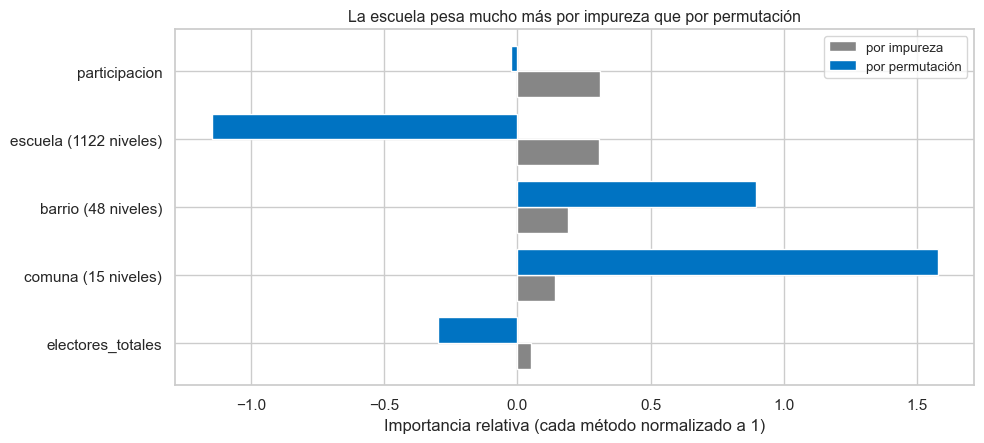

In [24]:
fig, ax = plt.subplots(figsize=(10, 4.6))
t = comparacion_imp.copy()
t = t / t.sum()                       # a proporciones, para poder compararlas
t = t.sort_values("por impureza")
pos = np.arange(len(t))
ancho = 0.38
ax.barh(pos - ancho/2, t["por impureza"], ancho, color=PALETA[3], label="por impureza")
ax.barh(pos + ancho/2, t["por permutación"], ancho, color=PALETA[0],
        label="por permutación")
ax.set_yticks(pos); ax.set_yticklabels(t.index)
ax.set_xlabel("Importancia relativa (cada método normalizado a 1)")
ax.set_title("La escuela pesa mucho más por impureza que por permutación", fontsize=11.5)
ax.legend(fontsize=9.5)
plt.tight_layout()
plt.show()

La diferencia es la esperada: la importancia por impureza le asigna a `escuela` una porción
del total mucho mayor que la permutación. El mecanismo es el que anticipamos: 1.122 niveles
ofrecen muchísimos cortes candidatos, y algunos reducen la impureza por azar.

Pero la permutación **no** la manda exactamente a cero. ¿Entonces aporta algo, o no? Para
responder eso hace falta medir la exactitud con y sin ella — y antes de eso, revisar un supuesto
que la escuela pone en cuestión.

## ¿Son independientes las observaciones?

Antes de responder cuánto aporta la escuela hay que revisar un supuesto que la validación
cruzada da por sentado: que las observaciones son **independientes**.

Y no lo son de manera obvia: **seis mesas de la misma escuela comparten el mismo barrio, el
mismo edificio y aproximadamente el mismo electorado**. Si algunas mesas de una escuela caen
en entrenamiento y otras en validación, el modelo puede estar "reconociendo" la escuela en
lugar de generalizando — el cuarto tipo de fuga de información de `9.0`.

Se mide primero, se corrige después.

escuelas con al menos 3 mesas: 1118
  unánimes (todas sus mesas con la misma ganadora): 40.0%
  proporción media de la lista dominante dentro de la escuela: 0.826


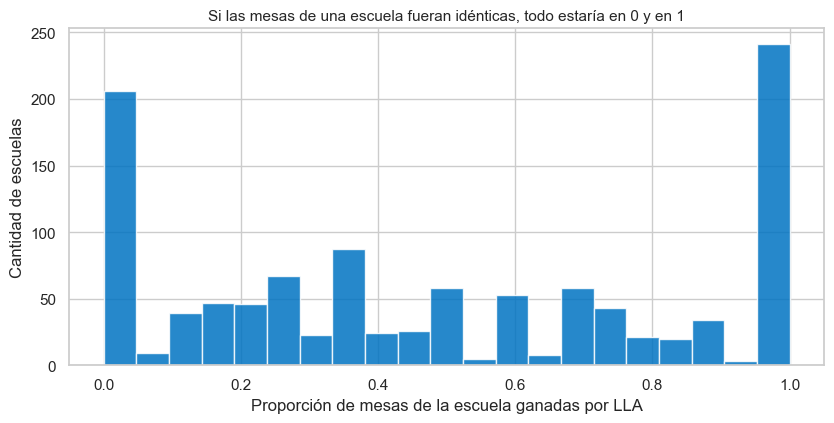

In [25]:
# ¿Qué tan homogéneas son las mesas de una misma escuela?
por_escuela = datos.groupby("escuela")["ganador"].agg(
    mesas="size", prop_lla=lambda s: (s == "la_libertad_avanza").mean())
con_varias = por_escuela[por_escuela["mesas"] >= 3]

unanimes = ((con_varias["prop_lla"] == 0) | (con_varias["prop_lla"] == 1)).mean()
dominante = np.maximum(con_varias["prop_lla"], 1 - con_varias["prop_lla"]).mean()

print(f"escuelas con al menos 3 mesas: {len(con_varias)}")
print(f"  unánimes (todas sus mesas con la misma ganadora): {unanimes:.1%}")
print(f"  proporción media de la lista dominante dentro de la escuela: {dominante:.3f}")

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.hist(con_varias["prop_lla"], bins=21, color=PALETA[0], alpha=0.85, edgecolor="white")
ax.set_xlabel("Proporción de mesas de la escuela ganadas por LLA")
ax.set_ylabel("Cantidad de escuelas")
ax.set_title("Si las mesas de una escuela fueran idénticas, todo estaría en 0 y en 1",
             fontsize=11)
plt.tight_layout()
plt.show()

Las mesas de una misma escuela **se parecen pero no son iguales**: la lista dominante se lleva
en promedio el 83% de las mesas de su escuela, y solo el 40% de las escuelas son unánimes. El
histograma tiene masa en los extremos pero también en el medio.

Eso significa que hay dependencia, pero que la etiqueta **no es determinística dentro de la
escuela**. Para saber si eso produce fuga hay que comparar dos esquemas de validación:

In [26]:
# StratifiedGroupKFold: los mismos pliegues estratificados, pero sin partir escuelas
CV_GRUPO = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

comparacion_cv = []
for nombre_X, XX, pre in [("sin escuela", X, preprocesador),
                          ("con escuela", X_esc, pre_esc)]:
    modelo = Pipeline([("pre", pre),
                       ("clf", RandomForestClassifier(n_estimators=300,
                                                      random_state=SEED, n_jobs=-1))])
    s1 = cross_validate(modelo, XX, y_bin, cv=CV, scoring=["accuracy"], n_jobs=-1)
    s2 = cross_validate(modelo, XX, y_bin, cv=CV_GRUPO, scoring=["accuracy"],
                        groups=datos["escuela"], n_jobs=-1)
    comparacion_cv.append({
        "predictores": nombre_X,
        "StratifiedKFold": s1["test_accuracy"].mean(),
        "sd_normal": s1["test_accuracy"].std(),
        "StratifiedGroupKFold": s2["test_accuracy"].mean(),
        "sd_grupo": s2["test_accuracy"].std(),
        "diferencia": s1["test_accuracy"].mean() - s2["test_accuracy"].mean(),
    })

pd.DataFrame(comparacion_cv).round(4)

,predictores,StratifiedKFold,sd_normal,StratifiedGroupKFold,sd_grupo,diferencia
0,sin escuela,0.7290,0.0145,0.7387,0.0154,-0.0097
1,con escuela,0.7287,0.0069,0.7641,0.0105,-0.0354


### El resultado, que no es el que uno esperaría

La fuga por agrupamiento tiene una firma reconocible: el esquema que **parte** los grupos
debería dar una exactitud **más alta** que el que los respeta, porque el primero deja que el
modelo reconozca grupos ya vistos. O sea, esperaríamos `StratifiedKFold` > `StratifiedGroupKFold`.

**Se observa exactamente lo contrario.** Con `escuela` entre los predictores, el esquema que
respeta los grupos da 0.764 y el que los parte da 0.729: el que "debería" estar inflado es el
más bajo. Sin `escuela` pasa lo mismo, con una diferencia menor.

Entonces la conclusión firme es: **no hay evidencia de que nuestras estimaciones estén
infladas por fuga por agrupamiento.** Eso es lo que había que verificar, y quedó verificado.

Sobre por qué la diferencia va en la otra dirección conviene ser prudente, porque los dos
esquemas **no responden la misma pregunta** y por eso no son estrictamente comparables:

- `StratifiedKFold` estima *qué tan bien predigo una mesa nueva de una escuela que conozco*.
- `StratifiedGroupKFold` estima *qué tan bien predigo en una escuela entera que nunca vi*.

En el segundo escenario las 1.122 columnas de `escuela` valen cero en el pliegue de validación
—son categorías no vistas— así que el modelo se apoya en barrio y participación. Que eso rinda
**mejor** sugiere que los efectos por escuela estimados sobre 4 o 5 mesas son sobre todo ruido:
memorizarlos no ayuda a predecir mesas nuevas ni siquiera en la misma escuela.

Eso responde la pregunta que quedó abierta sobre la alta cardinalidad: **`escuela` no aporta
señal que valga 1.122 columnas.** La exactitud con y sin ella es indistinguible bajo el
esquema aleatorio (0.7287 contra 0.7290). Lo que la importancia por impureza señalaba como la
segunda variable del modelo, medido correctamente, no aporta nada.

La lección general no es "el agrupamiento no importa" sino **"hay que chequearlo"**. En otros
diseños —varias respuestas del mismo encuestado, el mismo país medido en años distintos, mesas
de un padrón que se repite entre elecciones— la diferencia entre los dos esquemas es grande, va
en la dirección del optimismo, y usar el esquema equivocado invalida el resultado.

## Boosting: árboles en secuencia

Random Forest ajusta árboles **en paralelo** e independientes entre sí. El boosting hace lo
opuesto: ajusta árboles **en secuencia**, y cada uno se especializa en lo que los anteriores
hicieron mal.

La idea, en su forma más simple (*gradient boosting*):

1. Empezar con una predicción constante.
2. Calcular los **residuos**: en qué se equivoca el modelo actual.
3. Ajustar un árbol **chico** —un *weak learner*, típicamente de profundidad 2 a 5— que prediga
   esos residuos.
4. Sumarlo al modelo, multiplicado por una **tasa de aprendizaje** $\eta$ pequeña.
5. Repetir.

$$ F_m(x) = F_{m-1}(x) + \eta \, h_m(x) $$

La diferencia conceptual con el bagging es total. Bagging reduce **varianza** promediando modelos
de bajo sesgo. Boosting reduce **sesgo** sumando modelos de bajo poder individual. Y por eso el
boosting **sí puede sobreajustar** si se lo deja correr.

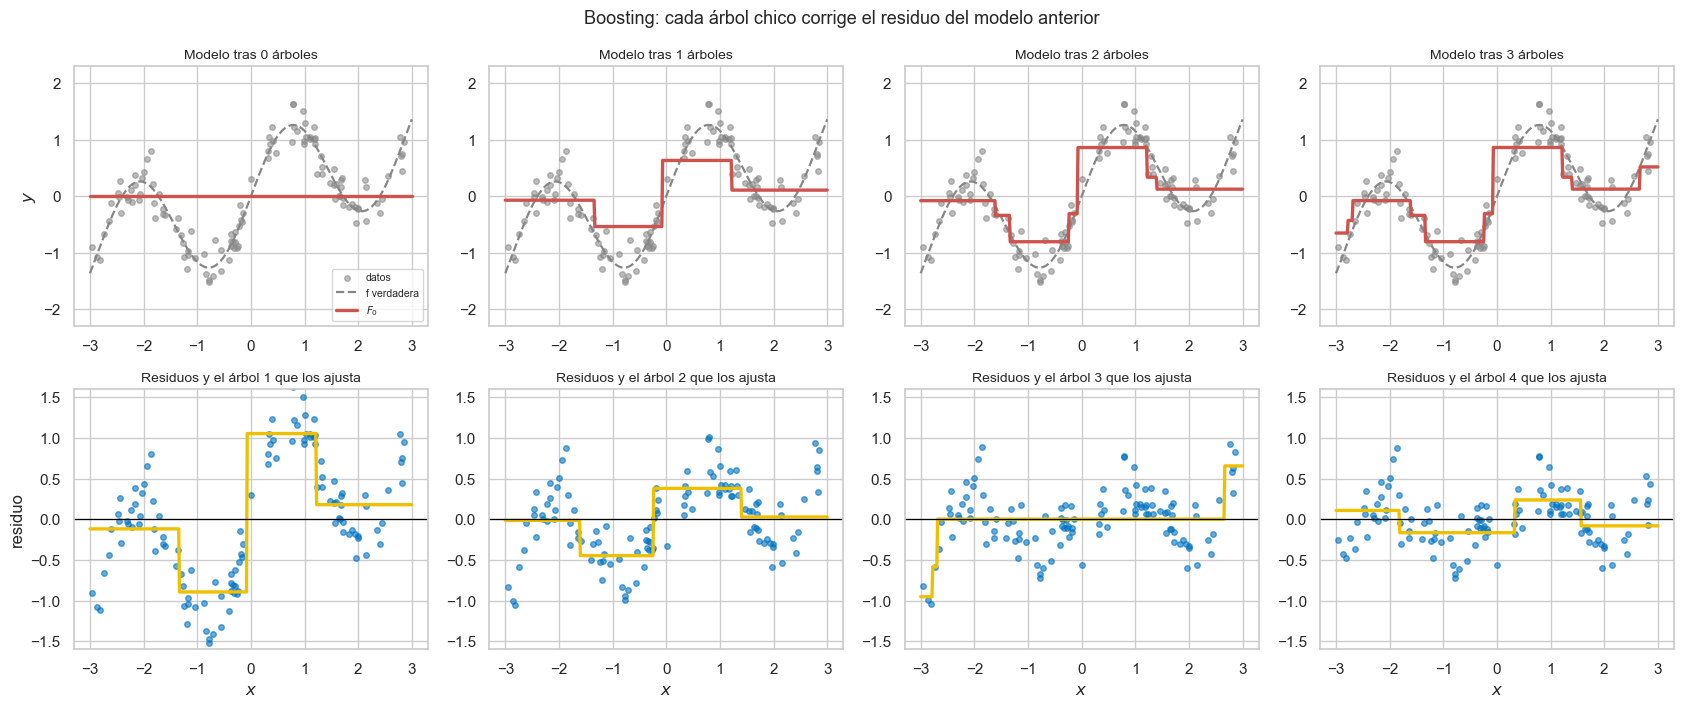

In [27]:
# La intuición del boosting sobre un problema de regresión de una variable
from sklearn.tree import DecisionTreeRegressor

rng_b = np.random.default_rng(SEED)
def f_real(x):
    return np.sin(2.2 * x) + 0.35 * x

x_b = np.sort(rng_b.uniform(-3, 3, 120))
y_b = f_real(x_b) + rng_b.normal(scale=0.22, size=120)
malla = np.linspace(-3, 3, 400)

eta = 0.6
prediccion = np.full_like(y_b, y_b.mean())
pred_malla = np.full_like(malla, y_b.mean())

fig, axes = plt.subplots(2, 4, figsize=(17, 7.2))
for it in range(4):
    residuo = y_b - prediccion
    arbolito = DecisionTreeRegressor(max_depth=2, random_state=SEED).fit(x_b[:, None], residuo)

    ax = axes[0, it]
    ax.scatter(x_b, y_b, s=16, color=PALETA[3], alpha=0.55, label="datos")
    ax.plot(malla, f_real(malla), color=PALETA[3], ls="--", lw=1.6, label="f verdadera")
    ax.plot(malla, pred_malla, color=PALETA[2], lw=2.4, label=f"$F_{{{it}}}$")
    ax.set_title(f"Modelo tras {it} árboles", fontsize=10)
    ax.set_ylim(-2.3, 2.3)
    if it == 0:
        ax.legend(fontsize=7.5, loc="lower right")

    ax = axes[1, it]
    ax.scatter(x_b, residuo, s=16, color=PALETA[0], alpha=0.6)
    ax.plot(malla, arbolito.predict(malla[:, None]), color=PALETA[1], lw=2.4)
    ax.axhline(0, color="black", lw=0.9)
    ax.set_title(f"Residuos y el árbol {it + 1} que los ajusta", fontsize=10)
    ax.set_ylim(-1.6, 1.6)
    ax.set_xlabel("$x$")

    prediccion = prediccion + eta * arbolito.predict(x_b[:, None])
    pred_malla = pred_malla + eta * arbolito.predict(malla[:, None])

axes[0, 0].set_ylabel("$y$")
axes[1, 0].set_ylabel("residuo")
fig.suptitle("Boosting: cada árbol chico corrige el residuo del modelo anterior", fontsize=13)
plt.tight_layout()
plt.show()

Arriba, el modelo acumulado va tomando la forma de la función verdadera. Abajo, los residuos se
van achicando y perdiendo estructura: cuando ya no queda patrón en los residuos, no hay nada más
que aprender.

### La familia: AdaBoost, Gradient Boosting, XGBoost

- **AdaBoost** (1995) fue el primero. En lugar de residuos, **repondera las observaciones**: las
  mal clasificadas pesan más en la iteración siguiente.
- **Gradient Boosting** (2001) generalizó la idea: los residuos son el gradiente negativo de una
  función de pérdida, y así el método sirve para cualquier pérdida diferenciable. AdaBoost resulta
  ser el caso particular con pérdida exponencial.
- **XGBoost** (2016) es una implementación de gradient boosting con dos aportes que importan acá:
  usa la **segunda derivada** de la pérdida (no solo el gradiente), y agrega **regularización
  explícita L1 y L2 sobre los valores de las hojas**, más una penalización por cantidad de hojas.

Ese último punto conecta directamente con `9.1`: la función objetivo de XGBoost es

$$ \mathcal{L} = \sum_i \ell(y_i, \hat y_i)
   + \sum_m \Big[ \gamma \, |T_m| + \tfrac{1}{2}\lambda \|w_m\|^2 + \alpha \|w_m\|_1 \Big] $$

con $\lambda$ el parámetro Ridge, $\alpha$ el Lasso y $\gamma$ el precio de cada hoja — que es la
poda por complejidad-costo de más arriba. **Es la misma caja de herramientas.**

<figure style="text-align:center; margin:1.4em 0;">
  <img src="media/xgboost.png" width="620">
  <figcaption style="font-size:0.9em; color:#555;">
    El esquema de un ensamble por boosting: cada árbol recibe un submuestreo de los datos, y el
    <em>residuo</em> de cada uno alimenta al siguiente. La predicción final es una suma ponderada.
  </figcaption>
</figure>

Comparar este esquema con el de Random Forest de más arriba deja ver la diferencia de fondo entre
las dos familias. En el bosque las flechas van **todas en paralelo** desde el caso nuevo hacia
árboles independientes. Acá hay una **flecha horizontal**: el residuo de un árbol es el insumo del
siguiente, y por eso el orden importa y el ensamble no se puede paralelizar del mismo modo.

### Los hiperparámetros que importan

| Parámetro | Qué controla | Regla práctica |
|---|---|---|
| `learning_rate` ($\eta$) | cuánto aporta cada árbol | bajo (0.01-0.1) predice mejor y necesita más árboles |
| `n_estimators` | cuántos árboles | se fija alto y se corta con *early stopping* |
| `max_depth` | complejidad de cada árbol | 2 a 6; más profundo capta interacciones y sobreajusta |
| `subsample` | fracción de filas por árbol | < 1 agrega aleatoriedad y reduce varianza |
| `reg_lambda`, `reg_alpha` | penalización de las hojas | subir si sobreajusta |

$\eta$ y `n_estimators` se compensan entre sí: bajar la tasa de aprendizaje a la mitad requiere
aproximadamente el doble de árboles. Lo vamos a ver medido.

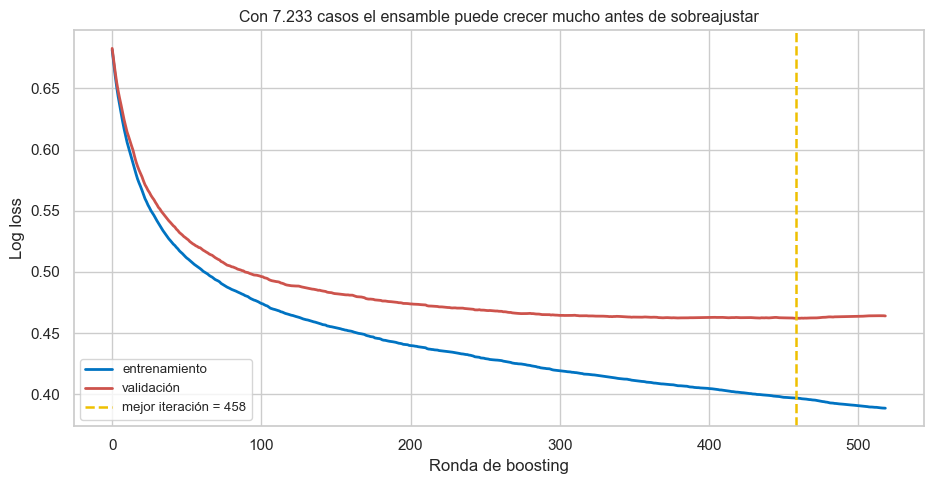

rondas solicitadas: 2000   |   usadas: 459


In [28]:
Xb_tr, Xb_val, yb_tr, yb_val = train_test_split(X, y_bin, test_size=0.25,
                                                random_state=SEED, stratify=y_bin)
pre_fit = preprocesador.fit(Xb_tr)
Mtr, Mval = pre_fit.transform(Xb_tr), pre_fit.transform(Xb_val)

xgb = XGBClassifier(n_estimators=2000, max_depth=5, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                    eval_metric="logloss", early_stopping_rounds=60,
                    random_state=SEED, n_jobs=-1)
xgb.fit(Mtr, yb_tr, eval_set=[(Mtr, yb_tr), (Mval, yb_val)], verbose=False)

hist = xgb.evals_result()
fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(hist["validation_0"]["logloss"], lw=2, color=PALETA[0], label="entrenamiento")
ax.plot(hist["validation_1"]["logloss"], lw=2, color=PALETA[2], label="validación")
ax.axvline(xgb.best_iteration, color=PALETA[1], ls="--", lw=1.8,
           label=f"mejor iteración = {xgb.best_iteration}")
ax.set_xlabel("Ronda de boosting"); ax.set_ylabel("Log loss")
ax.set_title("Con 7.233 casos el ensamble puede crecer mucho antes de sobreajustar",
             fontsize=11.5)
ax.legend(fontsize=9.5)
plt.tight_layout()
plt.show()

print(f"rondas solicitadas: 2000   |   usadas: {xgb.best_iteration + 1}")

El ensamble sostiene cientos de rondas antes de que la validación empiece a subir. En `9.3b`,
con 132 casos, el *early stopping* corta en pocas decenas: los datos se agotan enseguida.
**Esa es la diferencia que hace el tamaño de la muestra**, y es la razón por la que el boosting
tiene fama de ser el mejor método para datos tabulares — la fama se construyó con datasets
grandes.

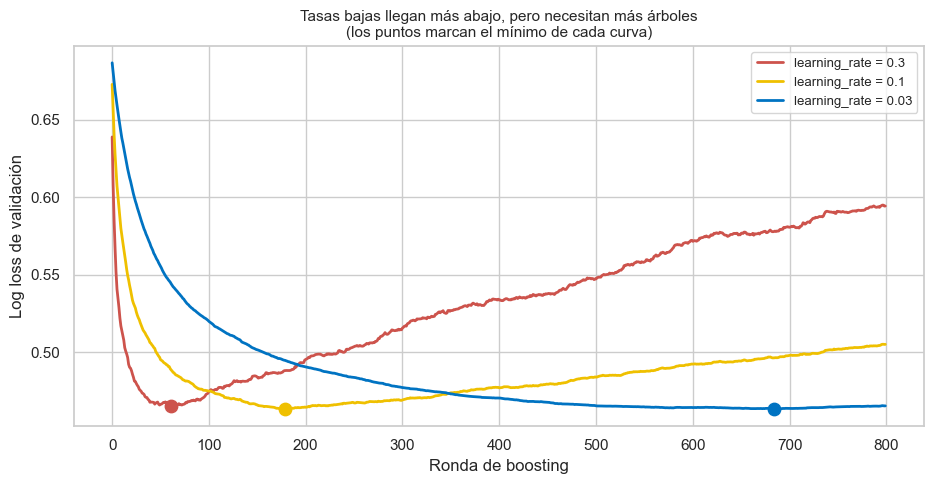

In [29]:
# Efecto de la tasa de aprendizaje
fig, ax = plt.subplots(figsize=(9.5, 5))
for eta, color in [(0.3, PALETA[2]), (0.1, PALETA[1]), (0.03, PALETA[0])]:
    m = XGBClassifier(n_estimators=800, max_depth=5, learning_rate=eta,
                      subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                      eval_metric="logloss", random_state=SEED, n_jobs=-1)
    m.fit(Mtr, yb_tr, eval_set=[(Mval, yb_val)], verbose=False)
    curva = m.evals_result()["validation_0"]["logloss"]
    ax.plot(curva, lw=2, color=color, label=f"learning_rate = {eta}")
    k = int(np.argmin(curva))
    ax.scatter([k], [curva[k]], s=80, color=color, zorder=5)

ax.set_xlabel("Ronda de boosting"); ax.set_ylabel("Log loss de validación")
ax.set_title("Tasas bajas llegan más abajo, pero necesitan más árboles\n"
             "(los puntos marcan el mínimo de cada curva)", fontsize=11)
ax.legend(fontsize=9.5)
plt.tight_layout()
plt.show()

### Cómo son los árboles del ensamble

Los árboles del boosting son deliberadamente chicos: ninguno predice bien por sí solo. La fuerza
está en la suma de cientos de correcciones pequeñas, que es exactamente lo contrario de la lógica
de Random Forest, donde cada árbol es un predictor completo.

Para verlos usamos el gradient boosting de scikit-learn, que guarda sus árboles como objetos que
`plot_tree` sabe dibujar. Es el mismo algoritmo de la familia y la misma función que usamos con el
árbol individual.

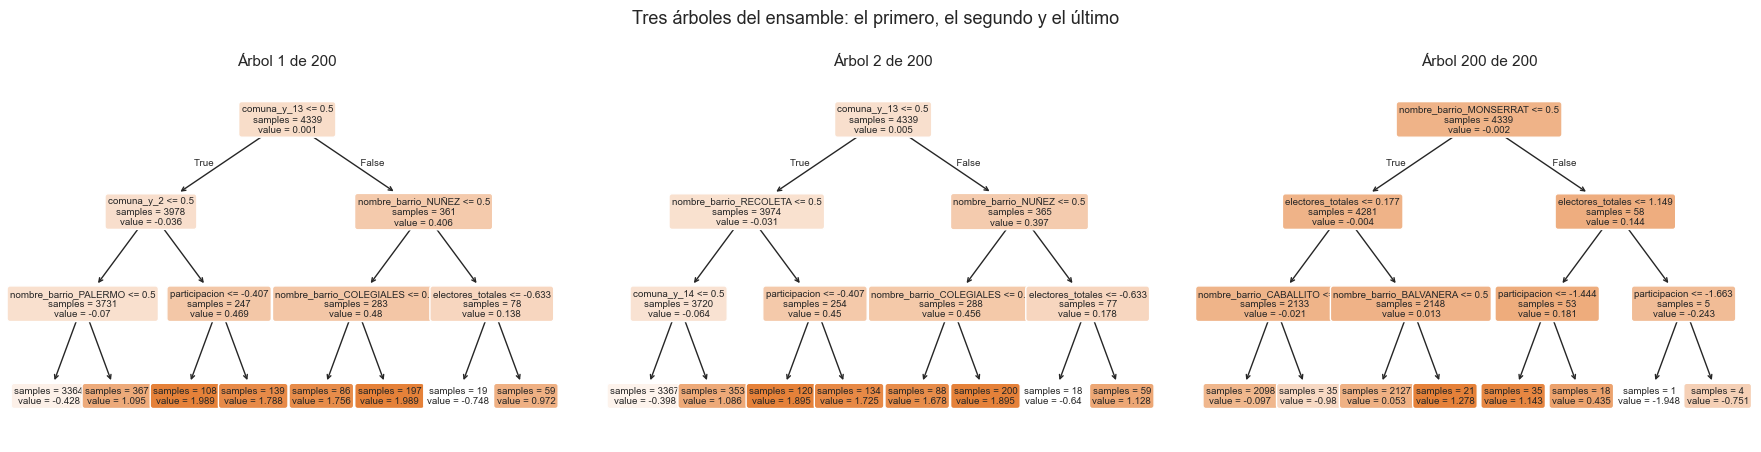

Valores de las hojas (el aporte de cada árbol a la predicción):
  árbol   1: rango [-0.748, +1.989]
  árbol   2: rango [-0.640, +1.895]
  árbol 200: rango [-1.948, +1.278]


In [30]:
# Un gradient boosting de sklearn guarda sus árboles como objetos que plot_tree
# puede dibujar, así que se ven con la misma función del árbol individual.
gbm = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                                 subsample=0.8, random_state=SEED).fit(Mtr, yb_tr)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))
for ax, k in zip(axes, [0, 1, 199]):
    plot_tree(gbm.estimators_[k, 0], feature_names=list(nombres), filled=True,
              rounded=True, impurity=False, fontsize=7, ax=ax)
    ax.set_title(f"Árbol {k + 1} de {gbm.n_estimators_}", fontsize=11)
fig.suptitle("Tres árboles del ensamble: el primero, el segundo y el último", fontsize=13)
plt.tight_layout()
plt.show()

print("Valores de las hojas (el aporte de cada árbol a la predicción):")
for k in [0, 1, 199]:
    hojas = gbm.estimators_[k, 0].tree_.value.ravel()
    hojas = hojas[gbm.estimators_[k, 0].tree_.children_left == -1]
    print(f"  árbol {k + 1:3d}: rango [{hojas.min():+.3f}, {hojas.max():+.3f}]")

## La comparación

In [31]:
modelos = [
    ("BASELINE (clase mayoritaria)", con_pre(DummyClassifier(strategy="most_frequent"))),
    ("Logística regularizada", con_pre(LogisticRegression(C=1.0, max_iter=5000,
                                                          random_state=SEED))),
    ("Árbol prof. 3", con_pre(DecisionTreeClassifier(max_depth=3, random_state=SEED))),
    (f"Árbol prof. óptima ({etiquetas_prof[mejor_i]})",
     con_pre(DecisionTreeClassifier(max_depth=profundidades[mejor_i], random_state=SEED))),
    ("Árbol sin podar", con_pre(DecisionTreeClassifier(random_state=SEED))),
    ("Random Forest, por defecto", con_pre(RandomForestClassifier(
        n_estimators=300, random_state=SEED, n_jobs=-1))),
    ("Random Forest, hojas ≥ 5", con_pre(RandomForestClassifier(
        n_estimators=300, min_samples_leaf=5, random_state=SEED, n_jobs=-1))),
    ("XGBoost (500, lr=0.05)", con_pre(XGBClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, reg_lambda=1.0, eval_metric="logloss",
        random_state=SEED, n_jobs=-1))),
]

POR_NOMBRE = dict(modelos)      # para referirnos a cada modelo sin depender del orden

tabla = pd.DataFrame([evaluar(est, X, y_bin, nombre) for nombre, est in modelos])
tabla = tabla.sort_values("exactitud", ascending=False).reset_index(drop=True)
tabla.round(4)

,modelo,exactitud,exac_sd,f1_macro,roc_auc
0,"XGBoost (500, lr=0.05)",0.7752,0.0067,0.7750,0.8552
1,"Random Forest, hojas ≥ 5",0.7722,0.0101,0.7720,0.8531
2,Logística regularizada,0.7568,0.0104,0.7565,0.8396
3,Árbol prof. óptima (15),0.7486,0.0134,0.7476,0.7888
4,"Random Forest, por defecto",0.7290,0.0145,0.7290,0.8161
5,Árbol sin podar,0.7155,0.0122,0.7152,0.7374
6,Árbol prof. 3,0.6664,0.0124,0.6373,0.6740
7,BASELINE (clase mayoritaria),0.5027,0.0003,0.3345,0.5000


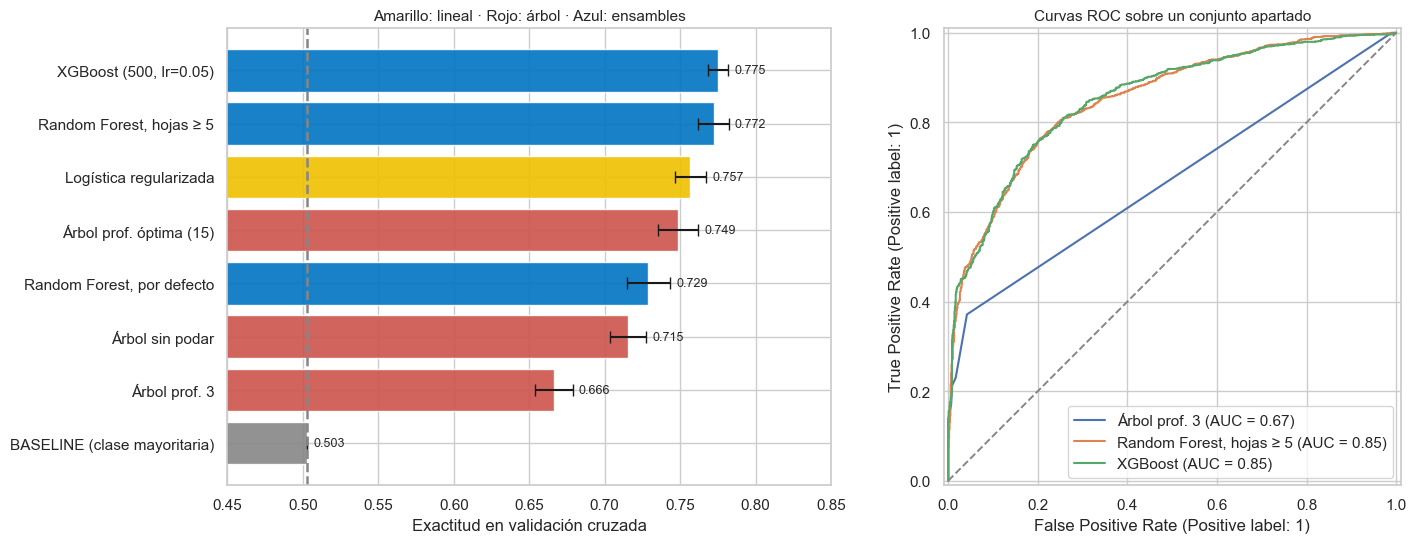

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))

t = tabla.sort_values("exactitud")
colores = []
for m in t["modelo"]:
    if m.startswith("BASELINE"):
        colores.append(PALETA[3])
    elif "Logística" in m:
        colores.append(PALETA[1])
    elif "Árbol" in m:
        colores.append(PALETA[2])
    else:
        colores.append(PALETA[0])
axes[0].barh(t["modelo"], t["exactitud"], xerr=t["exac_sd"], capsize=4,
             color=colores, alpha=0.9)
axes[0].axvline(0.5027, color=PALETA[3], ls="--", lw=1.8)
axes[0].set_xlim(0.45, 0.85)
axes[0].set_xlabel("Exactitud en validación cruzada")
axes[0].set_title("Amarillo: lineal · Rojo: árbol · Azul: ensambles", fontsize=11)
for i, (v, s) in enumerate(zip(t["exactitud"], t["exac_sd"])):
    axes[0].text(v + s + 0.004, i, f"{v:.3f}", va="center", fontsize=9)

for nombre, est in [("Árbol prof. 3", POR_NOMBRE["Árbol prof. 3"]),
                    ("Random Forest, hojas ≥ 5", POR_NOMBRE["Random Forest, hojas ≥ 5"]),
                    ("XGBoost", POR_NOMBRE["XGBoost (500, lr=0.05)"])]:
    est.fit(X_tr, y_tr)
    RocCurveDisplay.from_estimator(est, X_te, y_te, ax=axes[1], name=nombre)
axes[1].plot([0, 1], [0, 1], ls="--", color=PALETA[3], lw=1.4)
axes[1].set_title("Curvas ROC sobre un conjunto apartado", fontsize=11)

plt.tight_layout()
plt.show()

### Cómo se lee la tabla

Aparece la progresión que la teoría predice, pero con dos matices que vale mirar de frente:

| Modelo | Exactitud | Sobre el baseline |
|---|---|---|
| Baseline | 0.503 | — |
| Árbol de profundidad 3 | 0.666 | +16 puntos |
| Árbol sin podar | 0.716 | +21 puntos |
| **Random Forest, por defecto** | **0.729** | +23 puntos |
| Árbol con profundidad óptima (15) | 0.749 | +25 puntos |
| Regresión logística | 0.757 | +25 puntos |
| **Random Forest con hojas ≥ 5** | **0.772** | +27 puntos |
| **XGBoost** | **0.775** | **+27 puntos** |

**Primer matiz: Random Forest con los valores por defecto queda por debajo de un árbol único
bien calibrado.** 0.729 contra 0.749. Eso contradice la intuición de que un ensamble siempre
mejora, y tiene una explicación precisa.

Más arriba vimos que `n_estimators` no sobreajusta, y es verdad. Pero de ahí se sigue con
frecuencia una conclusión falsa: que Random Forest no necesita calibración. **La cantidad de
árboles no sobreajusta; la profundidad de cada árbol sí.** Y el valor por defecto de
scikit-learn es `min_samples_leaf=1`, o sea árboles crecidos hasta hojas de una sola
observación. Con solo cuatro predictores el submuestreo de variables no alcanza a decorrelacionar
lo suficiente, y el promedio de árboles sobreajustados sigue sobreajustado.

Poniendo `min_samples_leaf=5` —una restricción mínima— el bosque salta de **0.729 a 0.772** y
pasa a empatar con XGBoost. Cuatro puntos de exactitud por un solo hiperparámetro.

**Segundo matiz: la regresión logística se defiende bien.** Con 0.757 le gana a un árbol único
y al bosque sin calibrar, y queda a menos de dos puntos de los mejores ensambles. La
comparación honesta no es "los ensambles ganan por lejos" sino "los ensambles bien calibrados
ganan por unos dos puntos". Sigue siendo una ventaja real —dos puntos sobre 7.233 mesas son
unas 140 mesas mejor clasificadas— y sigue siendo mucho menos de lo que la fama del boosting
sugiere.

El AUC-ROC ordena igual que la exactitud, lo que confirma que el resultado no depende del
umbral de 0.5.

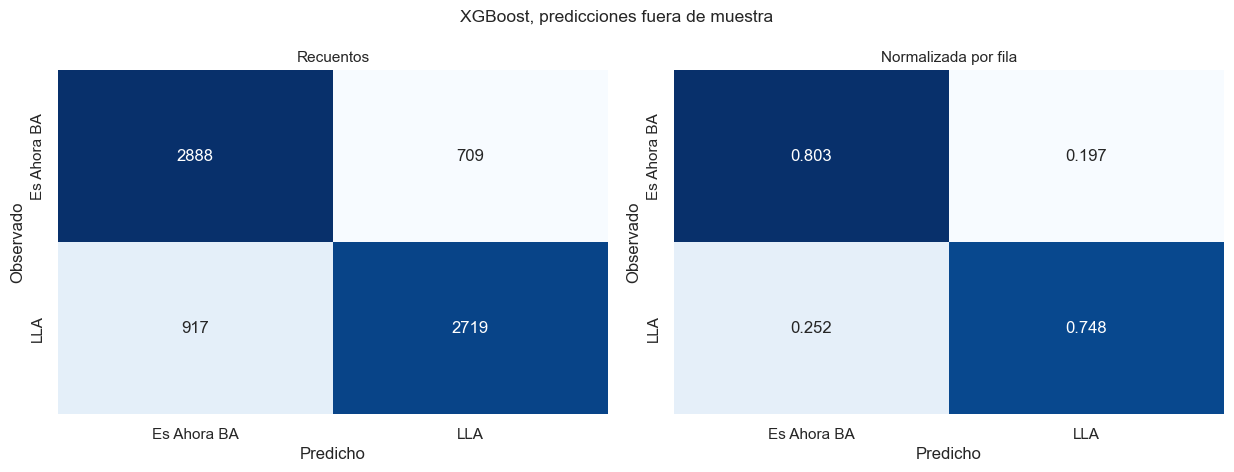

exactitud fuera de muestra: 0.7752


In [33]:
# La matriz de confusión del mejor modelo, fuera de muestra
mejor_modelo = POR_NOMBRE["XGBoost (500, lr=0.05)"]
y_pred = cross_val_predict(mejor_modelo, X, y_bin, cv=CV, n_jobs=-1)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
for ax, norm, titulo in [(axes[0], None, "Recuentos"),
                         (axes[1], "true", "Normalizada por fila")]:
    cm = confusion_matrix(y_bin, y_pred, normalize=norm)
    sns.heatmap(cm, annot=True, fmt="d" if norm is None else ".3f", cmap="Blues",
                xticklabels=["Es Ahora BA", "LLA"],
                yticklabels=["Es Ahora BA", "LLA"], cbar=False, ax=ax)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Observado"); ax.set_title(titulo, fontsize=11)
fig.suptitle("XGBoost, predicciones fuera de muestra", fontsize=12.5)
plt.tight_layout()
plt.show()

print(f"exactitud fuera de muestra: {accuracy_score(y_bin, y_pred):.4f}")

La matriz es casi simétrica: el modelo se equivoca de manera parecida en las dos direcciones.
Con clases balanceadas y sin costos asimétricos declarados, eso es lo deseable.

## Interpretar un ensamble

Un ensamble de cientos de árboles no se lee como reglas. Hay tres herramientas para abrirlo, de
menor a mayor detalle: la **importancia por permutación** que ya usamos, la **dependencia
parcial** y los **valores SHAP**.

La **dependencia parcial** muestra cómo cambia la predicción promedio al mover una variable,
manteniendo las demás como están. Su virtud es que **no supone linealidad**: si el modelo detectó
un efecto en forma de escalón o no monótono, acá se ve.

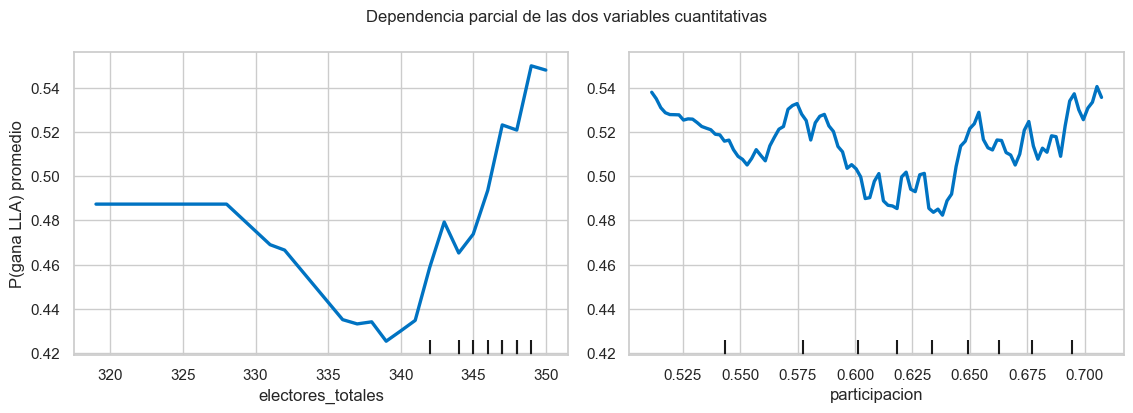

In [34]:
# Usamos el bosque calibrado, que quedó a 0.003 del XGBoost en la comparación
interpretable = POR_NOMBRE["Random Forest, hojas ≥ 5"]
interpretable.fit(X_tr, y_tr)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
PartialDependenceDisplay.from_estimator(
    interpretable, X_tr, NUMERICAS, ax=ax, kind="average",
    line_kw={"color": PALETA[0], "lw": 2.4})
ax[0].set_ylabel("P(gana LLA) promedio")
ax[1].set_ylabel("")
fig.suptitle("Dependencia parcial de las dos variables cuantitativas", fontsize=12)
plt.tight_layout()
plt.show()

La curva de la participación es **claramente no lineal y monótona creciente**: por debajo del 55%
la probabilidad de que gane LLA es baja y estable, sube con fuerza entre el 55% y el 70%, y se
aplana arriba. Una regresión logística solo podría aproximar eso con una recta en el logit, y ahí
está exactamente la ventaja de los ensambles en estos datos.

La del padrón es casi plana, coherente con su importancia por permutación cercana a cero.

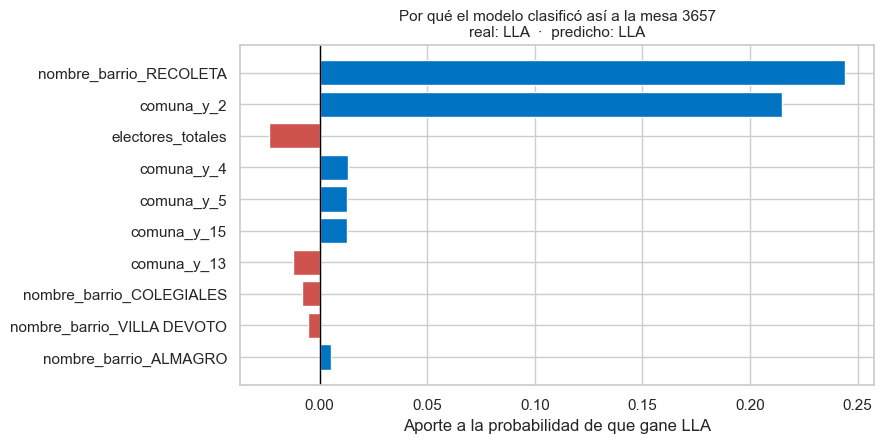

In [35]:
# SHAP: descomponer UNA predicción individual
try:
    import shap

    M_te = interpretable[:-1].transform(X_te)
    cols_shap = [n.split("__", 1)[1] for n in interpretable[:-1].get_feature_names_out()]
    explicador = shap.TreeExplainer(interpretable[-1])
    valores = np.asarray(explicador.shap_values(M_te))
    if valores.ndim == 3:                 # un valor por clase: tomamos la clase LLA
        valores = valores[..., 1]

    caso = 0
    aporte = pd.Series(valores[caso], index=cols_shap)
    aporte = aporte[aporte.abs() > 1e-9].sort_values(key=abs, ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(9, 4.6))
    ax.barh(aporte.index[::-1], aporte.values[::-1],
            color=[PALETA[0] if x > 0 else PALETA[2] for x in aporte.values][::-1])
    ax.axvline(0, color="black", lw=1)
    ax.set_xlabel("Aporte a la probabilidad de que gane LLA")
    real = "LLA" if y_te.iloc[caso] == 1 else "Es Ahora BA"
    pred = "LLA" if interpretable.predict(X_te.iloc[[caso]])[0] == 1 else "Es Ahora BA"
    ax.set_title(f"Por qué el modelo clasificó así a la mesa {X_te.index[caso]}"
                 f"\nreal: {real}  ·  predicho: {pred}", fontsize=11)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("shap no está instalado en este entorno; esta celda es opcional.")

SHAP responde una pregunta distinta de la importancia por permutación: no *qué variables importan
en general* sino **por qué este caso concreto recibió esta predicción**. Reparte la diferencia
entre la predicción del caso y la predicción promedio entre las variables, con una propiedad de la
teoría de juegos cooperativos —los valores de Shapley— que garantiza que los aportes suman
exactamente esa diferencia.

Es la herramienta indicada cuando hay que justificar una decisión individual, y por eso se volvió
estándar en contextos donde las predicciones tienen consecuencias.

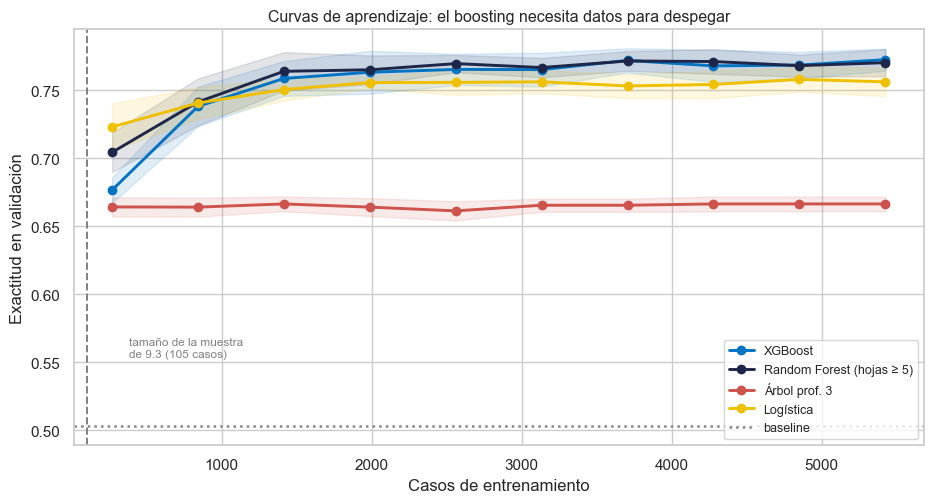

In [36]:
# Curva de aprendizaje: acá sí se aplana
fig, ax = plt.subplots(figsize=(9.5, 5.2))
for nombre, est, color in [
        ("XGBoost", POR_NOMBRE["XGBoost (500, lr=0.05)"], PALETA[0]),
        ("Random Forest (hojas ≥ 5)", POR_NOMBRE["Random Forest, hojas ≥ 5"], PALETA[4]),
        ("Árbol prof. 3", POR_NOMBRE["Árbol prof. 3"], PALETA[2]),
        ("Logística", POR_NOMBRE["Logística regularizada"], PALETA[1])]:
    tam, _, te_s = learning_curve(est, X, y_bin,
                                  train_sizes=np.linspace(0.05, 1.0, 10),
                                  cv=StratifiedKFold(4, shuffle=True, random_state=SEED),
                                  scoring="accuracy", n_jobs=-1)
    ax.plot(tam, te_s.mean(axis=1), "o-", lw=2.1, color=color, label=nombre)
    ax.fill_between(tam, te_s.mean(axis=1) - te_s.std(axis=1),
                    te_s.mean(axis=1) + te_s.std(axis=1), alpha=0.12, color=color)

ax.axhline(0.5027, color=PALETA[3], ls=":", lw=1.8, label="baseline")
ax.axvline(105, color="gray", ls="--", lw=1.4)
ax.annotate("tamaño de la muestra\nde 9.3 (105 casos)", (105, 0.56),
            xytext=(30, -6), textcoords="offset points", fontsize=8.5, color="gray")
ax.set_xlabel("Casos de entrenamiento")
ax.set_ylabel("Exactitud en validación")
ax.set_title("Curvas de aprendizaje: el boosting necesita datos para despegar", fontsize=11.5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Este gráfico es la respuesta a la pregunta con la que abrió el notebook.

En la zona izquierda —el rango donde vive la encuesta de `9.3b`, marcado con la línea vertical— las curvas
están mezcladas y la logística compite de igual a igual, o incluso adelante. A medida que crece
la muestra las curvas se separan: el árbol único se aplana enseguida, la logística se aplana
después, y las dos flexibles siguen subiendo. Al final el boosting y el bosque calibrado quedan
por encima de la lineal, con una brecha chica pero estable.

**La respuesta a "¿conviene un ensamble?" es: depende de cuántos casos haya.** No es una
propiedad del método sino de la relación entre la complejidad del modelo y la información
disponible, que es exactamente el compromiso sesgo-varianza de `9.0` visto desde otro ángulo.

## Cierre aplicado: el mapa de lo que el modelo no explica

El modelo predice el ganador de una mesa a partir de barrio, padrón y participación. Acierta
en unas tres de cada cuatro mesas. La pregunta aplicada es qué hacer con eso, y tiene dos
respuestas.

**La primera: dónde se define la elección.** Las mesas donde el modelo asigna una probabilidad
cercana a 0.5 son las competitivas — no las que el modelo predice mal, sino las que
genuinamente están en disputa según su estructura territorial. Ahí es donde un voto adicional
cambia el resultado.

**La segunda: dónde falla la lógica territorial.** Cuando el modelo predice con confianza y se
equivoca, ese territorio se comporta distinto de lo que su composición sugiere. Para un
analista, esas son las zonas que hay que ir a mirar de cerca.

In [37]:
proba = cross_val_predict(mejor_modelo, X, y_bin, cv=CV, method="predict_proba",
                          n_jobs=-1)[:, 1]

resultados = datos[["mesa", "escuela", "circuito", "nombre_barrio", "comuna_y",
                    "participacion", "electores_totales", "ganador", "margen"]].copy()
resultados["prob_lla"] = proba
resultados["gano_lla"] = y_bin.values
resultados["predicho_lla"] = (proba > 0.5).astype(int)
resultados["acierto"] = (resultados["predicho_lla"] == resultados["gano_lla"]).astype(int)
resultados["confianza"] = np.abs(proba - 0.5) * 2
resultados["competitiva"] = resultados["confianza"] < 0.2

print(f"exactitud global: {resultados['acierto'].mean():.4f}")
print(f"mesas competitivas (probabilidad entre 0.4 y 0.6): "
      f"{resultados['competitiva'].sum()} ({resultados['competitiva'].mean():.1%})")
print(f"\nexactitud en las competitivas: "
      f"{resultados.loc[resultados['competitiva'], 'acierto'].mean():.3f}")
print(f"exactitud en las de alta confianza (>0.8): "
      f"{resultados.loc[resultados['confianza'] > 0.8, 'acierto'].mean():.3f}")

exactitud global: 0.7752
mesas competitivas (probabilidad entre 0.4 y 0.6): 1148 (15.9%)

exactitud en las competitivas: 0.569
exactitud en las de alta confianza (>0.8): 0.959


La probabilidad predicha está **calibrada** en un sentido útil: donde el modelo dice estar
seguro acierta mucho más que donde dice dudar. Eso valida usar la confianza como medida de
competitividad, y no solo como medida de la performance del modelo.

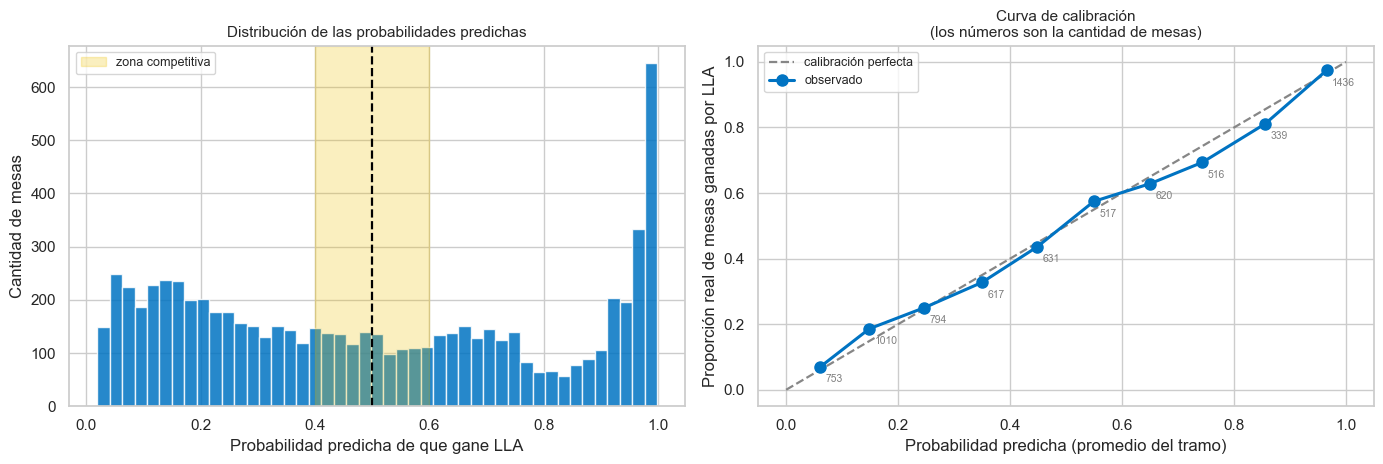

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].hist(proba, bins=45, color=PALETA[0], alpha=0.85, edgecolor="white")
axes[0].axvline(0.5, color="black", ls="--", lw=1.6)
axes[0].axvspan(0.4, 0.6, color=PALETA[1], alpha=0.25, label="zona competitiva")
axes[0].set_xlabel("Probabilidad predicha de que gane LLA")
axes[0].set_ylabel("Cantidad de mesas")
axes[0].set_title("Distribución de las probabilidades predichas", fontsize=11)
axes[0].legend(fontsize=9)

bins = np.linspace(0, 1, 11)
resultados["bin_prob"] = pd.cut(resultados["prob_lla"], bins, include_lowest=True)
cal = resultados.groupby("bin_prob", observed=True).agg(
    predicho=("prob_lla", "mean"), observado=("gano_lla", "mean"), n=("mesa", "size"))
axes[1].plot([0, 1], [0, 1], ls="--", color=PALETA[3], lw=1.6,
             label="calibración perfecta")
axes[1].plot(cal["predicho"], cal["observado"], "o-", lw=2.2, color=PALETA[0],
             ms=8, label="observado")
for _, f in cal.iterrows():
    axes[1].annotate(f"{int(f['n'])}", (f["predicho"], f["observado"]),
                     xytext=(4, -11), textcoords="offset points", fontsize=7.5,
                     color="gray")
axes[1].set_xlabel("Probabilidad predicha (promedio del tramo)")
axes[1].set_ylabel("Proporción real de mesas ganadas por LLA")
axes[1].set_title("Curva de calibración\n(los números son la cantidad de mesas)", fontsize=11)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [39]:
# Errores por barrio: ¿dónde falla la lógica territorial?
por_barrio = (resultados.groupby("nombre_barrio")
              .agg(mesas=("mesa", "size"),
                   tasa_acierto=("acierto", "mean"),
                   competitivas=("competitiva", "mean"),
                   margen_medio=("margen", "mean"),
                   participacion=("participacion", "mean"))
              .sort_values("tasa_acierto"))

print("Los 8 barrios donde el modelo falla más:")
print(por_barrio.head(8).round(3).to_string())
print("\nLos 5 barrios donde el modelo acierta más:")
print(por_barrio.tail(5).round(3).to_string())

Los 8 barrios donde el modelo falla más:
                   mesas  tasa_acierto  competitivas  margen_medio  participacion
nombre_barrio                                                                    
VILLA REAL            92         0.446         0.772         0.246          0.676
MONTE CASTRO          88         0.511         0.568         0.364          0.682
VILLA GRAL. MITRE    145         0.531         0.497         1.380          0.686
VILLA SANTA RITA      88         0.534         0.318        -0.851          0.678
VILLA CRESPO          37         0.541         0.243        -0.896          0.686
COGHLAN               52         0.577         0.577         1.717          0.667
VILLA URQUIZA        107         0.598         0.467        -0.882          0.690
CABALLITO            451         0.630         0.585        -0.177          0.675

Los 5 barrios donde el modelo acierta más:
               mesas  tasa_acierto  competitivas  margen_medio  participacion
nombre_barrio    

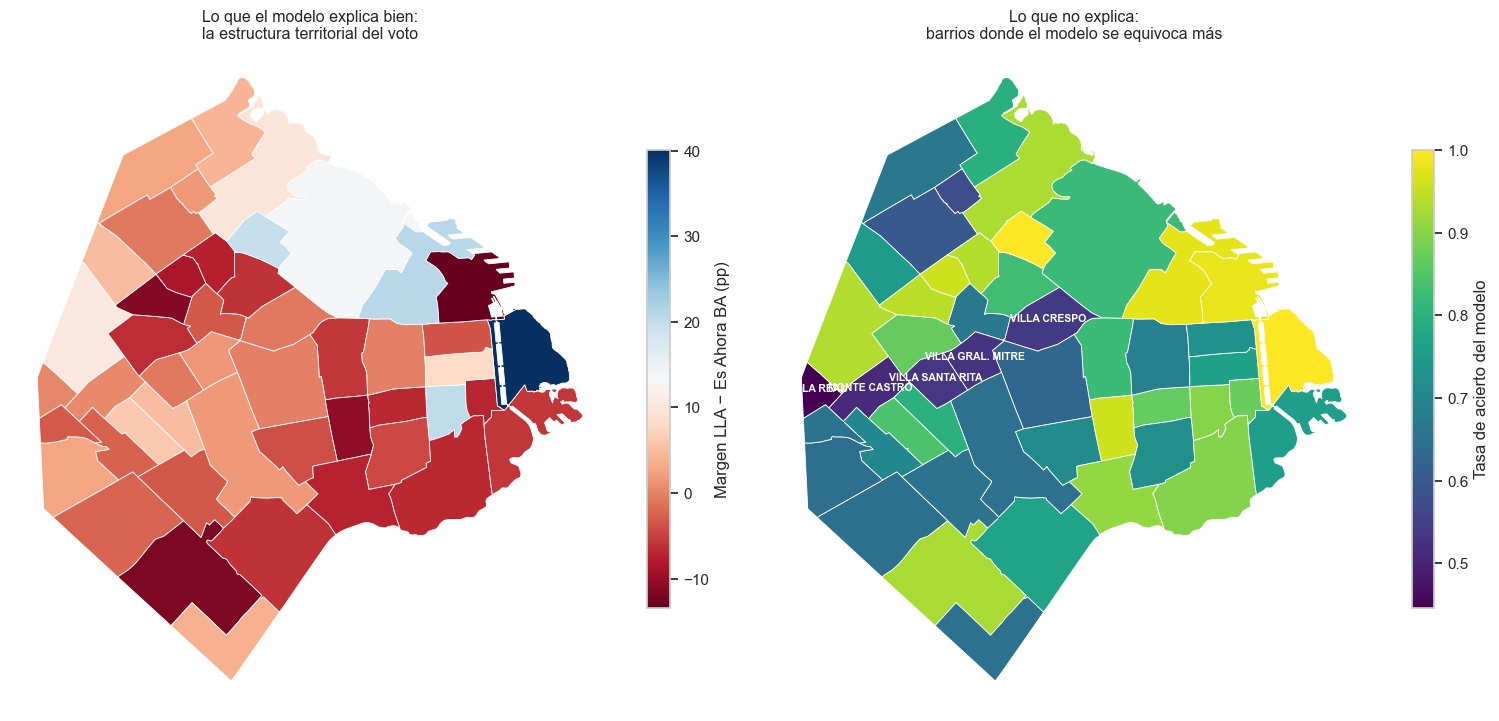

In [40]:
# El mapa
try:
    import geopandas as gpd

    barrios_gdf = gpd.read_file("../../dataset/barrios_caba/caba_barrios.geojson")
    barrios_gdf["nombre_barrio"] = barrios_gdf["BARRIO"]
    mapa = barrios_gdf.merge(por_barrio.reset_index(), on="nombre_barrio", how="left")

    fig, axes = plt.subplots(1, 2, figsize=(15.5, 8))

    mapa.plot(column="margen_medio", cmap="RdBu", legend=True, ax=axes[0],
              edgecolor="white", linewidth=0.6,
              legend_kwds={"label": "Margen LLA − Es Ahora BA (pp)", "shrink": 0.6})
    axes[0].set_title("Lo que el modelo explica bien:\nla estructura territorial del voto",
                      fontsize=11.5)
    axes[0].axis("off")

    mapa.plot(column="tasa_acierto", cmap="viridis", legend=True, ax=axes[1],
              edgecolor="white", linewidth=0.6,
              legend_kwds={"label": "Tasa de acierto del modelo", "shrink": 0.6})
    for _, f in mapa.nsmallest(5, "tasa_acierto").iterrows():
        c = f.geometry.centroid
        axes[1].annotate(f["nombre_barrio"], (c.x, c.y), fontsize=7.5,
                         ha="center", color="white", fontweight="bold")
    axes[1].set_title("Lo que no explica:\nbarrios donde el modelo se equivoca más",
                      fontsize=11.5)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
except ImportError:
    print("geopandas no está instalado en este entorno; el mapa es opcional.")
    print("Para instalarlo:  pip install geopandas")

In [41]:
# El producto: ranking de circuitos por competitividad
por_circuito = (resultados.groupby("circuito")
                .agg(mesas=("mesa", "size"),
                     electores=("electores_totales", "sum"),
                     prob_media_lla=("prob_lla", "mean"),
                     mesas_competitivas=("competitiva", "sum"),
                     margen_medio=("margen", "mean"),
                     barrio=("nombre_barrio", lambda s: s.mode().iloc[0]))
                .assign(pct_competitivas=lambda t: t["mesas_competitivas"] / t["mesas"]))

prioritarios = por_circuito.nlargest(12, "mesas_competitivas")
print("Circuitos a priorizar: los que concentran más mesas en disputa\n")
prioritarios[["barrio", "mesas", "electores", "mesas_competitivas",
              "pct_competitivas", "margen_medio"]].round(3)

Circuitos a priorizar: los que concentran más mesas en disputa



,barrio,mesas,electores,mesas_competitivas,pct_competitivas,margen_medio
circuito,,,,,,
86.0,FLORES,91,31525,58,0.637,-2.979
69.0,CABALLITO,79,27519,53,0.671,3.309
74.0,CABALLITO,69,23953,48,0.696,7.110
107.0,VILLA REAL,55,19089,45,0.818,-0.457
98.0,MATADEROS,71,24735,44,0.620,2.254
70.0,CABALLITO,73,25307,41,0.562,-4.368
73.0,CABALLITO,50,17393,40,0.800,-3.380
125.0,VILLA URQUIZA,56,19501,37,0.661,0.380
117.0,VILLA GRAL. MITRE,52,18024,34,0.654,-1.191


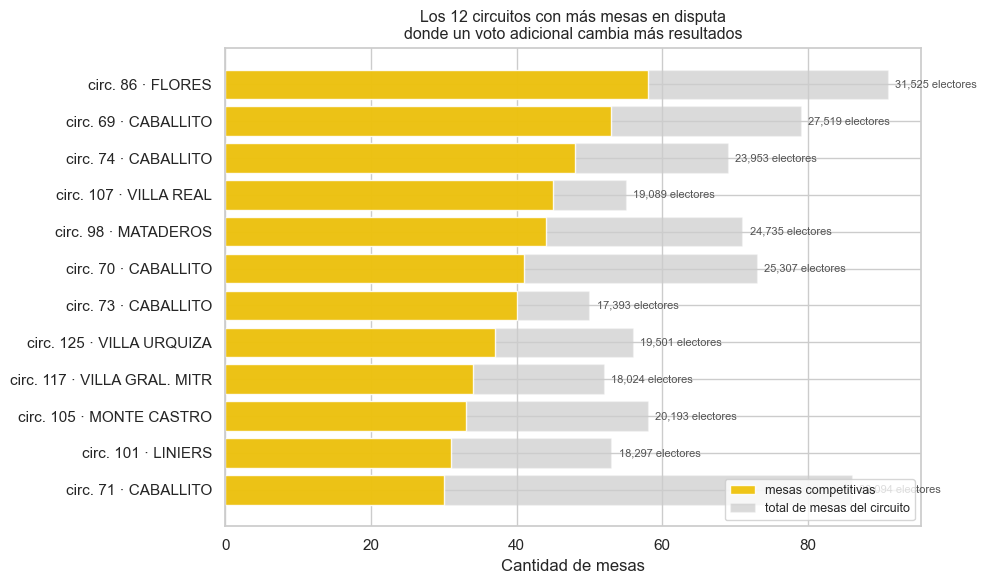

In [42]:
fig, ax = plt.subplots(figsize=(10, 6))
p = prioritarios.sort_values("mesas_competitivas")
etiquetas = [f"circ. {int(i)} · {r['barrio'][:16]}" for i, r in p.iterrows()]
ax.barh(etiquetas, p["mesas_competitivas"], color=PALETA[1], alpha=0.9,
        label="mesas competitivas")
ax.barh(etiquetas, p["mesas"], color=PALETA[3], alpha=0.30, zorder=0,
        label="total de mesas del circuito")
for i, (_, r) in enumerate(p.iterrows()):
    ax.text(r["mesas"] + 1, i, f"{r['electores']:,.0f} electores", va="center",
            fontsize=8, color="#555")
ax.set_xlabel("Cantidad de mesas")
ax.set_title("Los 12 circuitos con más mesas en disputa\n"
             "donde un voto adicional cambia más resultados", fontsize=11.5)
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

### El producto

Tres salidas concretas, todas usables por alguien que tenga que decidir dónde poner recursos:

1. **El ranking de circuitos en disputa.** No es el ranking de circuitos donde la elección
   estuvo pareja —eso se lee del resultado— sino de aquellos donde **la estructura territorial
   no determina el resultado**. Son los lugares donde la campaña, la organización y la
   fiscalización tienen margen para mover algo, y vienen con la cantidad de electores asociada
   para poder ponderar el esfuerzo.

2. **El mapa de los barrios donde falla el modelo.** Un barrio con tasa de acierto baja es un
   barrio internamente heterogéneo o con un comportamiento que su composición no anticipa. Son
   candidatos para trabajo cualitativo: entender qué pasa ahí que no pasa en barrios
   parecidos.

3. **Una medida de competitividad calibrada por mesa.** La curva de calibración muestra que la
   probabilidad predicha se corresponde con la frecuencia observada, así que sirve como
   insumo cuantitativo y no solo como ordenamiento.

Y una limitación que hay que decir: el modelo describe la elección de 2025, y su capacidad de
predecir la próxima depende de que la estructura territorial del voto se mantenga. Las
elecciones porteñas de la última década sugieren que se mantiene bastante, pero eso es un
supuesto sustantivo, no un resultado de este notebook.

## Síntesis

1. Con 7.233 mesas y un baseline de 0.503, todos los modelos le ganan al baseline por entre 16
   y 27 puntos, y el mejor es **XGBoost con 0.775**.

2. La curva de validación sobre `max_depth` tiene un **máximo claro** y la brecha entre
   entrenamiento y validación muestra la varianza. Con 132 casos, en `9.3b`, el mismo gráfico no
   muestra nada.

3. **`n_estimators` no sobreajusta, pero la profundidad de los árboles sí.** Random Forest con
   los valores por defecto de scikit-learn (`min_samples_leaf=1`) rinde **0.729**, por debajo de
   un árbol único bien calibrado. Poniendo `min_samples_leaf=5` sube a **0.772**. Que un método
   sea robusto no lo vuelve libre de hiperparámetros.

4. Los ensambles bien calibrados le ganan al modelo lineal, pero **por unos dos puntos**
   (0.775 y 0.772 contra 0.757), no por goleada. La ventaja es real y consistente —el efecto de
   la participación depende del barrio, o sea que hay interacción— y bastante menor que lo que
   la fama del boosting sugiere.

5. `escuela`, con **1.122 niveles**, es un caso real de la trampa de la alta cardinalidad: la
   importancia por impureza la señala como la segunda variable del modelo y, medida
   correctamente, **no aporta nada** (0.7287 con ella contra 0.7290 sin ella).

6. **La dependencia entre observaciones se chequea, no se supone.** Las mesas de una escuela
   son 83% homogéneas. La firma de la fuga por agrupamiento sería `StratifiedKFold` >
   `StratifiedGroupKFold`, y observamos lo contrario: no hay optimismo por agrupamiento acá. En
   otros diseños sí lo hay y usar el esquema equivocado invalida el resultado.

7. La curva de aprendizaje conjunta responde la pregunta del notebook: **por debajo de unos mil
   casos los métodos empatan; por encima, los flexibles se despegan.** "¿Conviene un ensamble?"
   no es una propiedad del método sino de la relación entre complejidad e información.

8. El cierre no es una métrica: es un **ranking de circuitos en disputa**, un **mapa de dónde
   falla la lógica territorial** y una **medida calibrada de competitividad por mesa** —donde el
   modelo dice estar seguro acierta el 96%, y donde dice dudar acierta el 57%.

## Comparación con la variante de 132 casos

| | `9.3b` · encuesta | `9.3` · mesas (este) |
|---|---|---|
| Casos | 132 | 7.233 |
| Predictores | 56 columnas | 62 columnas |
| Baseline | 0.545 | 0.503 |
| Árbol único, mejor versión | 0.671 | 0.749 |
| Random Forest | 0.788 | 0.772 |
| XGBoost | 0.765 | **0.775** |
| Modelo lineal | **0.791** | 0.757 |
| Ventaja del mejor ensamble sobre el lineal | **−0.003 (empatan)** | **+0.018** |
| ¿Sobreajusta el árbol sin podar? | sí, y no se nota | sí, y se ve en la curva |

Los dos notebooks usan los mismos métodos y casi el mismo código. Lo único que cambia de fondo es
la cantidad de datos, y el veredicto se invierte: con 132 casos el modelo lineal empata con el
mejor ensamble; con 7.233 los ensambles se ponen adelante.

**Esa es la lección que ninguno de los dos notebooks puede dar solo.** Y notar la magnitud:
incluso con 7.233 casos la ventaja del boosting sobre una regresión logística es de menos de dos
puntos. La elección del método casi nunca es lo que más mueve un resultado; los datos y las
variables sí.

## Lo que sigue

`9.3b.arboles-encuesta.ipynb` aplica todo esto a la encuesta de 132 casos de `9.2`, que es el
tamaño de muestra con el que van a trabajar en la práctica. Ahí los ensambles no ganan, y el
notebook cierra con una recomendación concreta de diseño de muestra.

Después de eso termina el bloque supervisado. En `9.4` desaparece la etiqueta y pasamos al
**aprendizaje no supervisado**, donde no hay respuesta correcta contra la que medirse y el
criterio del investigador vuelve al centro.